# Are Higher Manufacturer Payments Indicative of Higher Claims Reimbursements?

## Research Context

The relationship between pharmaceutical/device manufacturer payments to healthcare providers and subsequent Medicare claims reimbursements is a critical question in healthcare fraud analytics. The Open Payments program (Sunshine Act) mandates disclosure of manufacturer-to-provider transfers of value, while Medicare claims data captures the reimbursement side. If a systematic positive association exists, it could suggest that manufacturer financial relationships influence prescribing/ordering behavior in ways that inflate Medicare spending.

### Research Question
**Is there a statistically significant positive association between manufacturer payments received by healthcare providers and their Medicare claims reimbursement amounts, after controlling for provider specialty, patient risk, and practice characteristics?**

### Analytical Framework
1. **Descriptive Analysis** — Distributions, missingness, and summary statistics
2. **Bivariate Exploration** — Correlations, stratified comparisons, visualizations
3. **Stratified Analysis** — Specialty-level and payment-type breakdowns
4. **Multivariable Regression** — OLS and quantile regression with confounders
5. **Robustness Checks** — Log-transforms, outlier sensitivity, non-parametric tests

### Key Variables
| Role | Variable | Description |
|------|----------|-------------|
| **Exposure** | `total_payment` | Total manufacturer payments (Open Payments) |
| **Outcome** | `avg_suplr_mdcr_pymt_amt_sum` | Sum of average Medicare payment amounts across supplier lines |
| **Outcome** | `tot_suplr_clms_max` | Max total number of DMEPOS claims submitted by the highest-volume supplier for that referring provider |
| **Confounders** | `bene_avg_risk_scre`, `bene_cc_ph_diabetes_v2_pct`, `bene_cc_ph_copd_v2_pct`, specialty, `hi_risk_hcpcs` | DMEPOS case-mix, referral structure & practice characteristics |

In [1]:
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

# =============================================================================
# 1. COLORBLIND-FRIENDLY PALETTE  (Wong 2011, Nature Methods)
#    These 8 colors are maximally distinguishable for all color vision types.
# =============================================================================
CB_PALETTE = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # pink
    "#56B4E9",  # sky blue
    "#D55E00",  # vermillion
    "#F0E442",  # yellow
    "#000000",  # black
]

# =============================================================================
# 2. FONT DETECTION & SETTINGS
#    Auto-picks the best sans-serif font already on your machine.
#    Minimum size is 18pt; titles and labels are larger.
#
#    >>> To see ALL fonts available on your system, run in a cell:
#    >>>     from plot_template import list_fonts
#    >>>     list_fonts()
#
#    >>> To override the auto-picked font, set FONT_FAMILY before importing:
#    >>>     import plot_template
#    >>>     plot_template.FONT_FAMILY = "Verdana"
#    >>>     plot_template.apply_style()   # re-apply with your choice
# =============================================================================

def list_fonts(filter_text=None):
    """
    Print every font matplotlib can see on your system.
    Pass a string to filter, e.g. list_fonts("arial") or list_fonts("sans").
    """
    names = sorted({f.name for f in fm.fontManager.ttflist})
    if filter_text:
        names = [n for n in names if filter_text.lower() in n.lower()]
    print(f"Found {len(names)} font{'s' if len(names) != 1 else ''}:\n")
    for n in names:
        print(f"  • {n}")
    return names

# Preferred fonts in priority order (all clean presentation sans-serifs)
_FONT_PREFERENCES = [
    "Arial",
    "Helvetica",
    "Helvetica Neue",
    "Calibri",
    "Verdana",
    "Segoe UI",
    "Liberation Sans",
    "DejaVu Sans",
]

def _find_best_font():
    """Return the first preferred font that is actually installed."""
    available = {f.name for f in fm.fontManager.ttflist}
    for font in _FONT_PREFERENCES:
        if font in available:
            return font
    # Nothing from the preferred list — just grab any sans-serif we can find
    for name in sorted(available):
        if "sans" in name.lower():
            return name
    # True last resort
    return "DejaVu Sans"

FONT_FAMILY = _find_best_font()
print(f"Font: {FONT_FAMILY}")
FONT_SIZE_TITLE   = 30      # figure / axes title
FONT_SIZE_LABEL   = 24      # axis labels
FONT_SIZE_TICK    = 20      # tick labels
FONT_SIZE_LEGEND  = 20      # legend text
FONT_SIZE_ANNOT   = 18      # annotations / text on plot

# =============================================================================
# 3. APPLY GLOBAL STYLE (matplotlib + seaborn)
#    Called automatically on import. Call again after changing FONT_FAMILY.
# =============================================================================

def apply_style():
    """Apply (or re-apply) the full presentation style using current settings."""
    mpl.rcParams.update({
        # --- Font -----------------------------------------------------------
        "font.family":        "sans-serif",
        "font.sans-serif":    [FONT_FAMILY, "Helvetica", "DejaVu Sans"],
        "font.size":          FONT_SIZE_ANNOT,       # base / fallback size

        # --- Axes -----------------------------------------------------------
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelsize":     FONT_SIZE_LABEL,
        "axes.labelweight":   "bold",
        "axes.prop_cycle":    mpl.cycler(color=CB_PALETTE),
        "axes.linewidth":     1.5,
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.grid":          True,
        "axes.axisbelow":     True,                   # grid behind data

        # --- Ticks ----------------------------------------------------------
        "xtick.labelsize":    FONT_SIZE_TICK,
        "ytick.labelsize":    FONT_SIZE_TICK,
        "xtick.major.width":  1.5,
        "ytick.major.width":  1.5,
        "xtick.major.size":   6,
        "ytick.major.size":   6,
        "xtick.direction":    "out",
        "ytick.direction":    "out",

        # --- Grid -----------------------------------------------------------
        "grid.color":         "#dbdbdb",
        "grid.linewidth":     0.8,
        "grid.alpha":         1.0,

        # --- Legend ----------------------------------------------------------
        "legend.fontsize":    FONT_SIZE_LEGEND,
        "legend.frameon":     True,
        "legend.framealpha":  0.9,
        "legend.edgecolor":   "#999999",
        "legend.fancybox":    True,
        "legend.shadow":      False,
        "legend.loc":         "best",

        # --- Lines & markers ------------------------------------------------
        "lines.linewidth":    2.5,
        "lines.markersize":   10,

        # --- Figure ---------------------------------------------------------
        "figure.figsize":     (12, 7),
        "figure.dpi":         100,
        "figure.facecolor":   "white",
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",

        # --- Saving ---------------------------------------------------------
        "savefig.dpi":        300,
        "savefig.bbox":       "tight",
        "savefig.facecolor":  "white",
    })

    sns.set_theme(
        style="whitegrid",
        font=FONT_FAMILY,
        font_scale=1.4,
        rc=mpl.rcParams,
    )
    sns.set_palette(CB_PALETTE)

    # Re-assert settings that seaborn's set_theme can override
    mpl.rcParams.update({
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelweight":   "bold",
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",
        "grid.color":         "#dbdbdb",
        "grid.alpha":         1.0,
    })

# Auto-apply on import
apply_style()

# =============================================================================
# 5. HELPER FUNCTIONS
# =============================================================================

def add_legend(ax=None, title=None, **kwargs):
    """
    Add a styled legend to the current or specified axes.
    Merges template defaults with any overrides you pass in.
    """
    ax = ax or plt.gca()
    defaults = dict(
        fontsize=FONT_SIZE_LEGEND,
        frameon=True,
        framealpha=0.9,
        edgecolor="#999999",
        loc="best",
    )
    defaults.update(kwargs)
    legend = ax.legend(title=title, **defaults)
    if title:
        legend.get_title().set_fontsize(FONT_SIZE_LEGEND)
        legend.get_title().set_fontweight("bold")
    return legend


def get_colors(n=None):
    """
    Return the colorblind-friendly palette (or the first n colors).
    Useful when you need explicit color assignments.

    Usage:
        colors = get_colors(3)
        ax.bar(x, y1, color=colors[0], label="Group A")
        ax.bar(x, y2, color=colors[1], label="Group B")
    """
    if n is None:
        return CB_PALETTE.copy()
    return CB_PALETTE[:n]


def finalize(fig=None, tight=True):
    """
    Call at the end of every plot cell to tighten layout.
    """
    fig = fig or plt.gcf()
    if tight:
        fig.tight_layout()


Font: Liberation Sans


In [3]:
SEED = 69
np.random.seed(SEED)

## Load and Prepare Data

In [4]:
df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/unified_dataset_testing.csv")
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Year range: {df["year"].min()} – {df["year"].max()}')
print(f'Unique providers (NPI): {df["npi"].nunique():,}')
print(f'States: {df["rfrg_prvdr_state_abrvtn"].nunique()}')
df.head(3)

Dataset shape: 140,827 rows × 140 columns
Year range: 2021 – 2023
Unique providers (NPI): 63,117
States: 9


,npi,rfrg_prvdr_state_abrvtn,year,target,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_pymt_amt_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_sum,...,total_payment_outlier_by_type,bene_avg_age_outlier,bene_avg_age_zscore_by_type,bene_avg_age_outlier_by_type,bene_avg_risk_scre_outlier,bene_avg_risk_scre_outlier_by_type,drug_suplr_mdcr_stdzd_pymt_amt_outlier,drug_suplr_mdcr_stdzd_pymt_amt_outlier_by_type,elderly_patient_concentration,young_patient_concentration
0,1003000597,OK,2022,0,1.692306,1.692306,1.692306,1.0,0.0,3,...,False,False,-0.549574,False,False,False,False,False,0.0,0.0
1,1003000597,OK,2023,0,23.833223,0.112054,8.331875,5.0,0.0,12,...,False,False,-0.115403,False,False,False,False,False,0.0,0.0
2,1003000902,KY,2021,0,155.711788,0.087436,82.163333,5.0,3.0,32,...,False,False,-0.363841,False,False,False,False,False,0.0,0.0


In [5]:
##################################
# VARIABLES
###################################


# Exposure: manufacturer payments from Open Payments
EXPOSURE = 'total_payment'

# Payment sub-types (for decomposition analysis)
PAYMENT_NATURE_COLS = [
    'nature_sum_food_and_beverage', 'nature_sum_faculty_or_speaker',
    'nature_sum_entertainment', 'nature_sum_other_services',
    'nature_sum_acquisition', 'nature_sum_debt_forgiveness',
    'nature_sum_ownership_or_investment'
]

# Outcomes: Medicare reimbursement metrics
OUTCOMES = [
    'avg_suplr_mdcr_pymt_amt_sum',      # Total Medicare payment (sum across supplier lines)
    'tot_suplr_clms_max',       # Minimum single-supplier DMEPOS Medicare payment
    'avg_suplr_mdcr_pymt_amt_max'       # Maximum single-line Medicare payment
]

# Confounders (selected per CMS DMEPOS Referring Provider Data Dictionary, RY24)
CONFOUNDERS = [
    'bene_avg_risk_scre',                # Bene_Avg_Risk_Scre: Average HCC risk score
    'bene_cc_ph_diabetes_v2_pct',        # % with diabetes — major DMEPOS driver (glucose monitors, pumps)
    'bene_cc_ph_copd_v2_pct',            # % with COPD — drives respiratory DMEPOS (oxygen, nebulizers)
    'elderly_patient_concentration',     # Derived from Bene_Age_75_84_Cnt + Bene_Age_GT_84_Cnt
    'bene_dual_cnt',                     # Bene_Dual_Cnt: Medicare-only beneficiary count
    'tot_suplr_nonrntl_hcpcs_cds',      # Non-rental HCPCS count — breadth of non-rental product ordering
    'tot_suplr_rentl_hcpcs_cds',        # Rental HCPCS count — rental equipment (wheelchairs, hospital beds)
    'hi_risk_hcpcs',                     # Count of high-risk/fraud-prone HCPCS codes ordered
    'active_medicaid_provider_flag'      # Medicaid participation indicator
]

print('Variable groups defined.')
print(f'Exposure: {EXPOSURE}')
print(f'Outcomes: {OUTCOMES}')
print(f'Confounders: {CONFOUNDERS}')
print(f'Payment nature columns: {len(PAYMENT_NATURE_COLS)}')

Variable groups defined.
Exposure: total_payment
Outcomes: ['avg_suplr_mdcr_pymt_amt_sum', 'tot_suplr_clms_max', 'avg_suplr_mdcr_pymt_amt_max']
Confounders: ['bene_avg_risk_scre', 'bene_cc_ph_diabetes_v2_pct', 'bene_cc_ph_copd_v2_pct', 'elderly_patient_concentration', 'bene_dual_cnt', 'tot_suplr_nonrntl_hcpcs_cds', 'tot_suplr_rentl_hcpcs_cds', 'hi_risk_hcpcs', 'active_medicaid_provider_flag']
Payment nature columns: 7


In [6]:
##################################
# MISSINGNESS ASSESSMENT
###################################

key_cols = [EXPOSURE] + OUTCOMES + CONFOUNDERS + PAYMENT_NATURE_COLS
missing = df[key_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

miss_df = pd.DataFrame({'Missing N': missing, 'Missing %': missing_pct})
miss_df = miss_df[miss_df['Missing N'] > 0].sort_values('Missing %', ascending=False)

if miss_df.empty:
    print('No missing values in key analytical variables.')
else:
    print('Variables with missing values:')
    print(miss_df.to_string())

No missing values in key analytical variables.


In [7]:
##################################
# LOG TRANSFOROM
###################################

# Standard practice for right-skewed financial data (Manning & Mullahy, 2001)
# Using log1p (log(1+x)) to handle zeros

df['log_total_payment'] = np.log1p(df[EXPOSURE])
df['log_mdcr_pymt_sum'] = np.log1p(df['avg_suplr_mdcr_pymt_amt_sum'])
df['log_mdcr_pymt_min'] = np.log1p(df['tot_suplr_clms_max'])
df['log_mdcr_pymt_max'] = np.log1p(df['avg_suplr_mdcr_pymt_amt_max'])

# Payment receipt indicator (binary)
df['received_payment'] = (df[EXPOSURE] > 0).astype(int)

# Payment terciles (for stratified analysis)
payment_tercile = pd.Series('None', index=df.index, dtype='object')
pos_mask = df[EXPOSURE] > 0
tercile_labels = pd.qcut(
    df.loc[pos_mask, EXPOSURE],
    q=3, labels=['Low', 'Medium', 'High']
).astype(str)
payment_tercile.loc[pos_mask] = tercile_labels
df['payment_tercile'] = pd.Categorical(
    payment_tercile, categories=['None', 'Low', 'Medium', 'High'], ordered=True
)

print(f'Providers receiving any manufacturer payment: {df["received_payment"].sum():,} ({df["received_payment"].mean()*100:.1f}%)')
print(f'Providers with zero payments: {(df[EXPOSURE]==0).sum():,}')
print(f'\nPayment tercile distribution:')
print(df['payment_tercile'].value_counts().sort_index())

Providers receiving any manufacturer payment: 39,436 (28.0%)
Providers with zero payments: 101,391

Payment tercile distribution:
payment_tercile
None      101391
Low        13147
Medium     13143
High       13146
Name: count, dtype: int64


## Descriptive Statistics

In [8]:
##################################
# SUMMARY STATS
###################################

monetary_vars = [EXPOSURE] + OUTCOMES
desc = df[monetary_vars].describe(percentiles=[.25, .5, .75, .90, .95, .99]).T
desc['skewness'] = df[monetary_vars].skew()
desc['kurtosis'] = df[monetary_vars].kurtosis()
desc['zero_pct'] = ((df[monetary_vars] == 0).sum() / len(df) * 100).round(1)

print('Summary Statistics — Monetary Variables')
print('=' * 80)
desc[['count','mean','std','min','25%','50%','75%','99%','max','skewness','kurtosis','zero_pct']].round(2)

Summary Statistics — Monetary Variables


,count,mean,std,min,25%,50%,75%,99%,max,skewness,kurtosis,zero_pct
total_payment,140827.0,944.88,59799.95,0.0,0.00,0.00,16.89,6311.71,19867456.91,273.34,87609.67,72.0
avg_suplr_mdcr_pymt_amt_sum,140827.0,338.38,737.24,0.0,50.08,137.54,363.80,2474.04,94737.96,32.61,2956.33,0.0
tot_suplr_clms_max,140827.0,63.59,151.08,11.0,16.00,27.00,54.00,710.00,13871.00,16.69,899.92,0.0
avg_suplr_mdcr_pymt_amt_max,140827.0,195.73,436.33,0.0,38.71,88.94,192.84,1074.38,21564.13,12.63,296.09,0.0


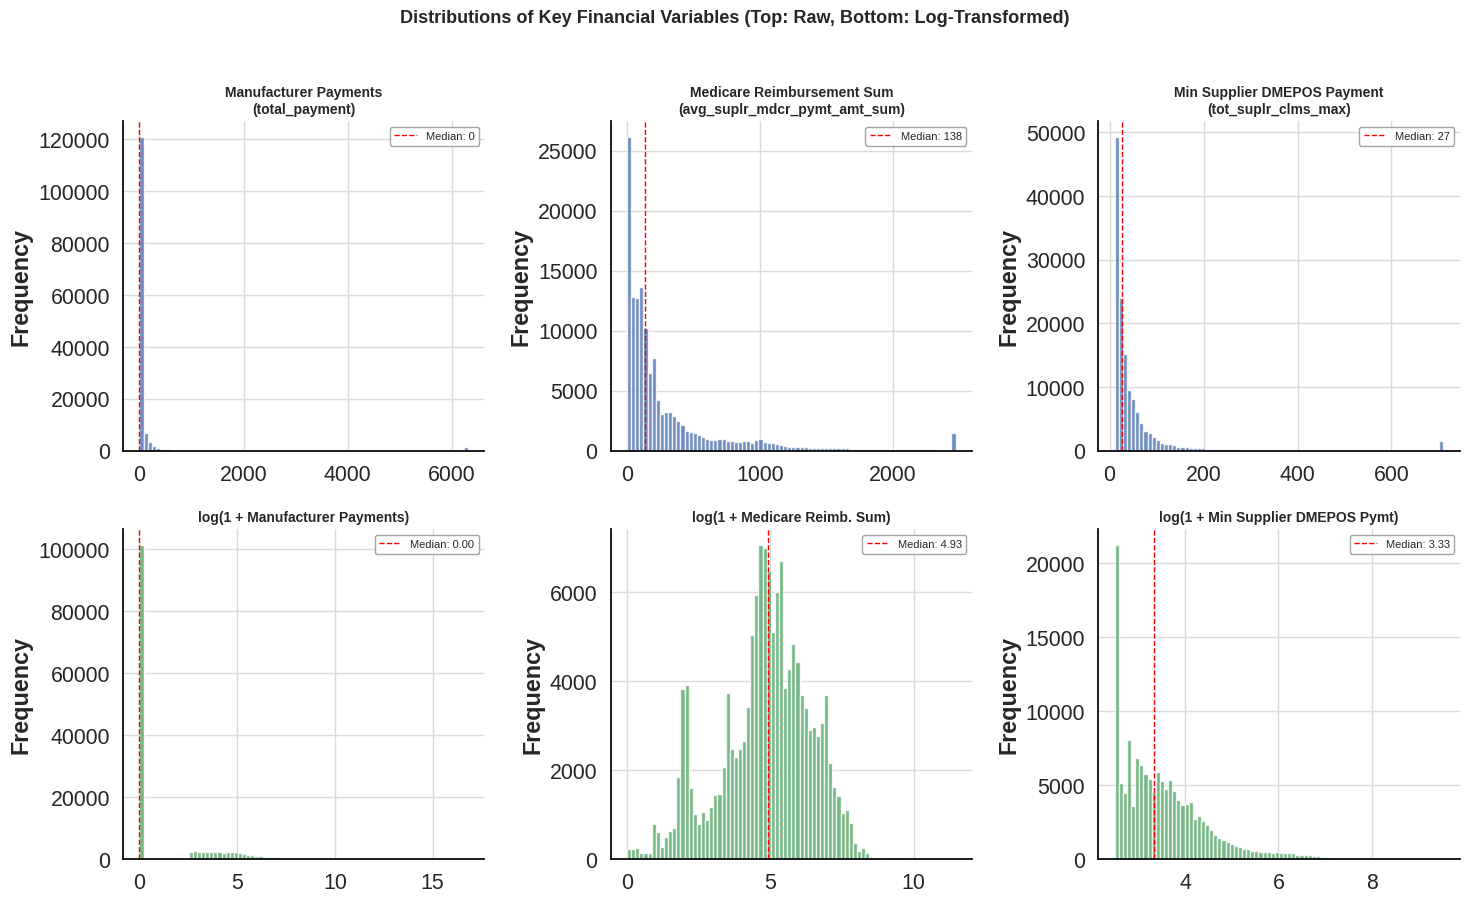


Note: Raw distributions clipped at 99th percentile for visualization. Log-transformation substantially reduces skewness, supporting its use in regression.


In [9]:
###########################################
# DISTRIBUTION PLOTS
###########################################
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

raw_vars = [EXPOSURE, 'avg_suplr_mdcr_pymt_amt_sum', 'tot_suplr_clms_max']
log_vars = ['log_total_payment', 'log_mdcr_pymt_sum', 'log_mdcr_pymt_min']
titles_raw = ['Manufacturer Payments\n(total_payment)',
              'Medicare Reimbursement Sum\n(avg_suplr_mdcr_pymt_amt_sum)',
              'Min Supplier DMEPOS Payment\n(tot_suplr_clms_max)']
titles_log = ['log(1 + Manufacturer Payments)',
              'log(1 + Medicare Reimb. Sum)',
              'log(1 + Min Supplier DMEPOS Pymt)']

for i, (var, title) in enumerate(zip(raw_vars, titles_raw)):
    ax = axes[0, i]
    data = df[var].clip(upper=df[var].quantile(0.99))  # clip for visualization
    ax.hist(data, bins=80, color='#4C72B0', edgecolor='white', alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Frequency')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1, label=f'Median: {data.median():,.0f}')
    ax.legend(fontsize=8)

for i, (var, title) in enumerate(zip(log_vars, titles_log)):
    ax = axes[1, i]
    ax.hist(df[var], bins=80, color='#55A868', edgecolor='white', alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Frequency')
    ax.axvline(df[var].median(), color='red', linestyle='--', linewidth=1, label=f'Median: {df[var].median():.2f}')
    ax.legend(fontsize=8)

fig.suptitle('Distributions of Key Financial Variables (Top: Raw, Bottom: Log-Transformed)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nNote: Raw distributions clipped at 99th percentile for visualization. '
      'Log-transformation substantially reduces skewness, supporting its use in regression.')

## Bivariate Analysis

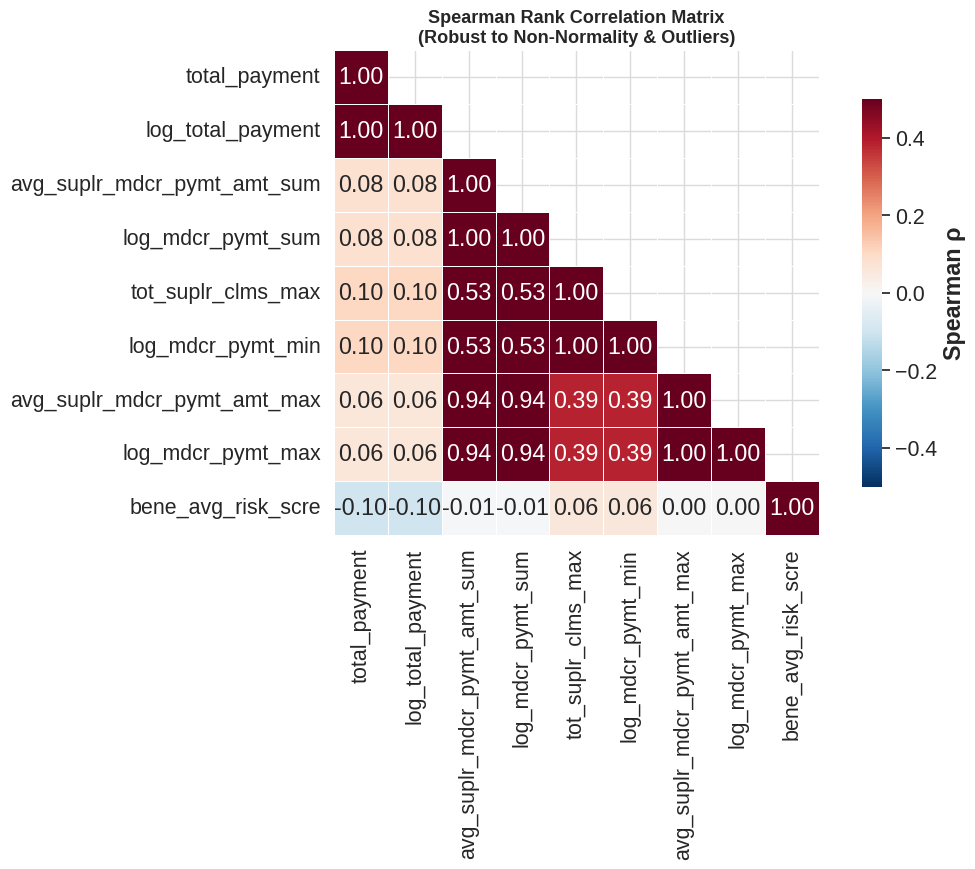


Key Bivariate Correlations
total_payment                            vs avg_suplr_mdcr_pymt_amt_sum             
   Spearman ρ = +0.0784 (p = 9.71e-191)  |  Pearson r = +0.0023 (p = 3.94e-01)
total_payment                            vs tot_suplr_clms_max                      
   Spearman ρ = +0.1019 (p = 0.00e+00)  |  Pearson r = -0.0010 (p = 7.09e-01)
total_payment                            vs avg_suplr_mdcr_pymt_amt_max             
   Spearman ρ = +0.0608 (p = 1.44e-115)  |  Pearson r = +0.0060 (p = 2.48e-02)
log_total_payment                        vs log_mdcr_pymt_sum                       
   Spearman ρ = +0.0784 (p = 9.71e-191)  |  Pearson r = +0.0653 (p = 7.84e-133)
log_total_payment                        vs log_mdcr_pymt_min                       
   Spearman ρ = +0.1019 (p = 0.00e+00)  |  Pearson r = +0.0943 (p = 1.69e-275)


In [10]:
###########################################
# CORRELATIONS
###########################################
corr_vars = ['total_payment', 'log_total_payment',
             'avg_suplr_mdcr_pymt_amt_sum', 'log_mdcr_pymt_sum',
             'tot_suplr_clms_max', 'log_mdcr_pymt_min',
             'avg_suplr_mdcr_pymt_amt_max', 'log_mdcr_pymt_max',
             'bene_avg_risk_scre']

# Spearman correlation (rank-based, appropriate for skewed data)
spearman_corr = df[corr_vars].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.5, vmax=0.5, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Spearman ρ'}, ax=ax)
ax.set_title('Spearman Rank Correlation Matrix\n(Robust to Non-Normality & Outliers)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Key correlations
print('\nKey Bivariate Correlations')
pairs = [
    ('total_payment', 'avg_suplr_mdcr_pymt_amt_sum'),
    ('total_payment', 'tot_suplr_clms_max'),
    ('total_payment', 'avg_suplr_mdcr_pymt_amt_max'),
    ('log_total_payment', 'log_mdcr_pymt_sum'),
    ('log_total_payment', 'log_mdcr_pymt_min'),
]
for x, y in pairs:
    rho, p = stats.spearmanr(df[x], df[y])
    r, p_pearson = stats.pearsonr(df[x], df[y])
    print(f'{x:40s} vs {y:40s}')
    print(f'   Spearman ρ = {rho:+.4f} (p = {p:.2e})  |  Pearson r = {r:+.4f} (p = {p_pearson:.2e})')

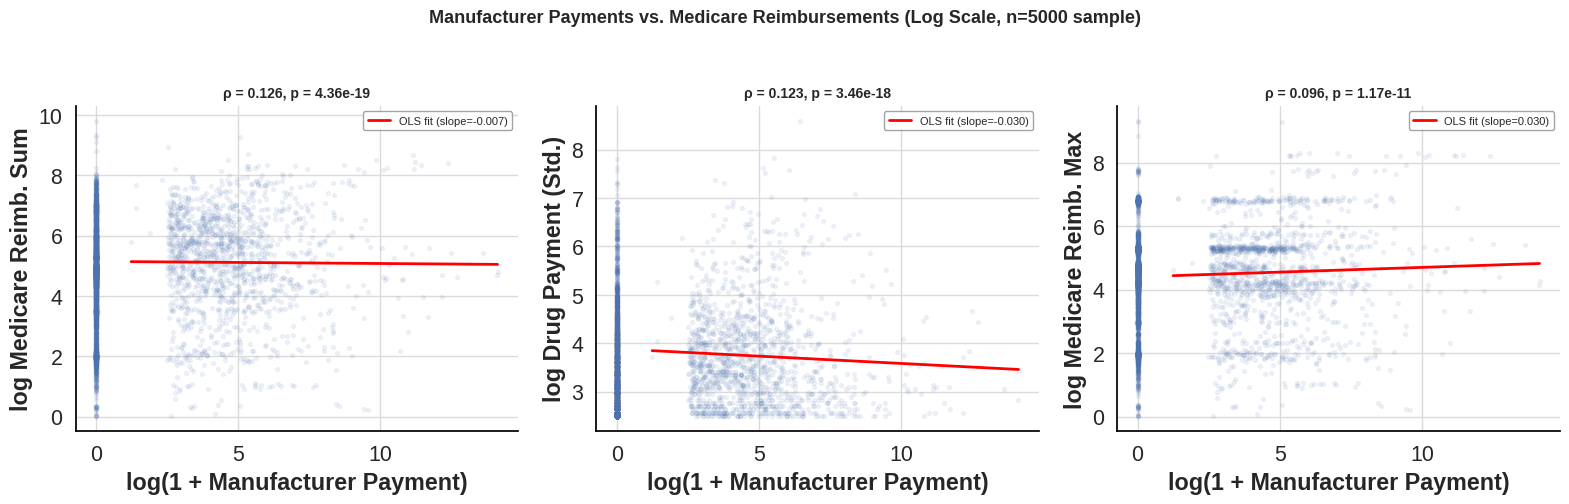

In [11]:
###########################################
# Scatter plots with LOWESS smoothing 
###########################################  

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter_pairs = [
    ('log_total_payment', 'log_mdcr_pymt_sum', 'log Medicare Reimb. Sum'),
    ('log_total_payment', 'log_mdcr_pymt_min', 'log Drug Payment (Std.)'),
    ('log_total_payment', 'log_mdcr_pymt_max', 'log Medicare Reimb. Max'),
]

for i, (x, y, ylabel) in enumerate(scatter_pairs):
    ax = axes[i]
    # Subsample for readability
    sample = df.sample(n=min(5000, len(df)), random_state=SEED)
    ax.scatter(sample[x], sample[y], alpha=0.08, s=8, color='#4C72B0', rasterized=True)
    
    # Fit line
    mask_valid = sample[[x, y]].notna().all(axis=1) & (sample[x] > 0)
    if mask_valid.sum() > 100:
        z = np.polyfit(sample.loc[mask_valid, x], sample.loc[mask_valid, y], 1)
        p = np.poly1d(z)
        xrange = np.linspace(sample.loc[mask_valid, x].min(), sample.loc[mask_valid, x].max(), 100)
        ax.plot(xrange, p(xrange), color='red', linewidth=2, label=f'OLS fit (slope={z[0]:.3f})')
    
    rho, pval = stats.spearmanr(sample[x], sample[y])
    ax.set_xlabel('log(1 + Manufacturer Payment)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'ρ = {rho:.3f}, p = {pval:.2e}', fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Manufacturer Payments vs. Medicare Reimbursements (Log Scale, n=5000 sample)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
######################################################################
# COMPARISON: Providers who received payments vs. those who did not 
######################################################################
# Mann-Whitney U test (non-parametric, appropriate for skewed distributions)

print(' Mann-Whitney U Tests: Received Payment vs. No Payment ')
print('H0: The distribution of Medicare reimbursements is the same for both groups.')
print('=' * 85)

for outcome in OUTCOMES:
    grp_yes = df.loc[df['received_payment'] == 1, outcome].dropna()
    grp_no  = df.loc[df['received_payment'] == 0, outcome].dropna()
    
    stat, p = stats.mannwhitneyu(grp_yes, grp_no, alternative='greater')
    # Rank-biserial correlation as effect size
    n1, n2 = len(grp_yes), len(grp_no)
    r_rb = 1 - (2 * stat) / (n1 * n2)  # rank-biserial
    
    print(f'\n{outcome}:')
    print(f'  Received payments (n={n1:,}):  Median = {grp_yes.median():>10,.2f}  Mean = {grp_yes.mean():>12,.2f}')
    print(f'  No payments       (n={n2:,}):  Median = {grp_no.median():>10,.2f}  Mean = {grp_no.mean():>12,.2f}')
    print(f'  Mann-Whitney U = {stat:,.0f}, p = {p:.4e}, rank-biserial r = {r_rb:+.4f}')
    if p < 0.001:
        print(f'  → Statistically significant at α = 0.001')
    elif p < 0.05:
        print(f'  → Statistically significant at α = 0.05')
    else:
        print(f'  → Not statistically significant at α = 0.05')

 Mann-Whitney U Tests: Received Payment vs. No Payment 
H0: The distribution of Medicare reimbursements is the same for both groups.

avg_suplr_mdcr_pymt_amt_sum:
  Received payments (n=39,436):  Median =     179.91  Mean =       441.52
  No payments       (n=101,391):  Median =     129.72  Mean =       298.27
  Mann-Whitney U = 2,227,129,722, p = 5.3081e-243, rank-biserial r = -0.1140
  → Statistically significant at α = 0.001

tot_suplr_clms_max:
  Received payments (n=39,436):  Median =      33.00  Mean =        81.08
  No payments       (n=101,391):  Median =      25.00  Mean =        56.78
  Mann-Whitney U = 2,287,983,054, p = 0.0000e+00, rank-biserial r = -0.1444
  → Statistically significant at α = 0.001

avg_suplr_mdcr_pymt_amt_max:
  Received payments (n=39,436):  Median =      98.19  Mean =       253.41
  No payments       (n=101,391):  Median =      86.81  Mean =       173.29
  Mann-Whitney U = 2,171,196,938, p = 2.2216e-139, rank-biserial r = -0.0860
  → Statistically signi

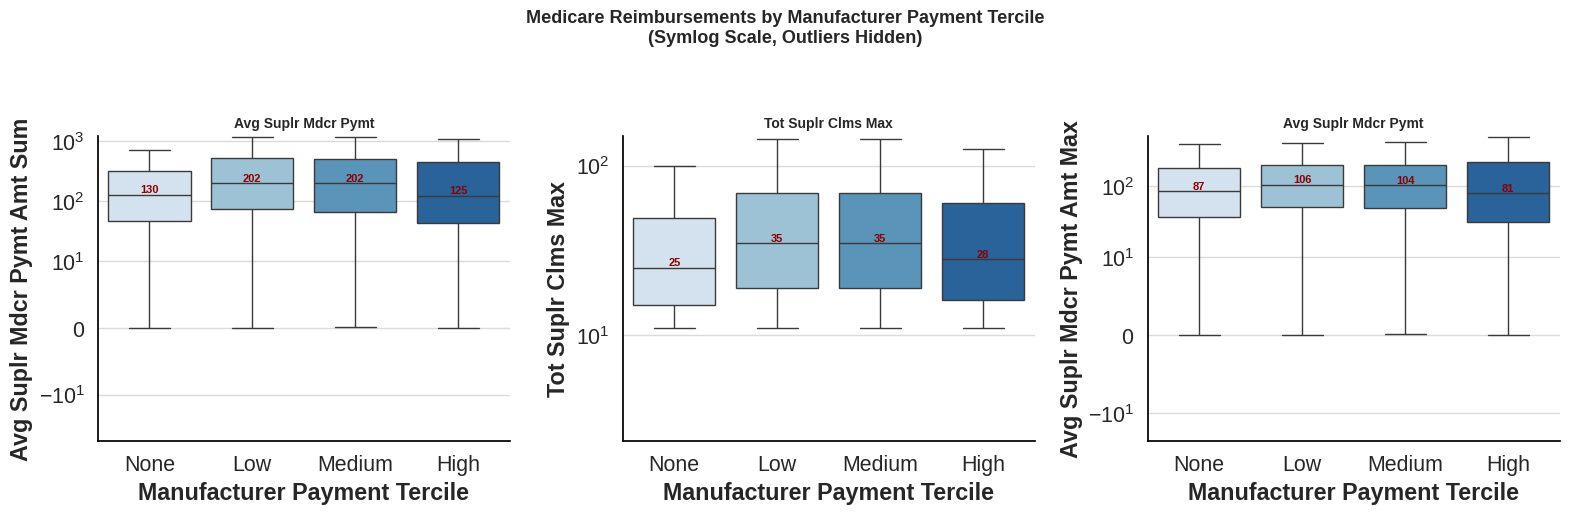

In [13]:
#  Box plots by payment tercile 

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, outcome in enumerate(OUTCOMES):
    ax = axes[i]
    # Use log scale for readability
    plot_data = df[['payment_tercile', outcome]].dropna()
    
    bp = sns.boxplot(data=plot_data, x='payment_tercile', y=outcome,
                     ax=ax, showfliers=False, palette='Blues',
                     order=['None', 'Low', 'Medium', 'High'])
    ax.set_yscale('symlog', linthresh=10)
    ax.set_xlabel('Manufacturer Payment Tercile')
    ax.set_ylabel(outcome.replace('_', ' ').title()[:40])
    ax.set_title(outcome.split('_amt')[0].replace('_', ' ').title(), fontsize=10)

    # Add median annotations
    medians = plot_data.groupby('payment_tercile', observed=True)[outcome].median()
    for j, (cat, med) in enumerate(medians.items()):
        ax.annotate(f'{med:,.0f}', xy=(j, med), ha='center', va='bottom',
                    fontsize=8, color='darkred', fontweight='bold')

fig.suptitle('Medicare Reimbursements by Manufacturer Payment Tercile\n(Symlog Scale, Outliers Hidden)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

In [14]:
######################################################################
# Kruskal-Wallis H-test across payment terciles 
#  Non-parametric one-way ANOVA analog
######################################################################
print(' Kruskal-Wallis H-Test: Medicare Reimbursement by Payment Tercile ')
print('H0: All payment groups have the same distribution of Medicare reimbursements.')
print('=' * 80)

for outcome in OUTCOMES:
    groups = [grp[outcome].dropna().values 
              for _, grp in df.groupby('payment_tercile', observed=True)]
    stat, p = stats.kruskal(*groups)
    # Effect size: eta-squared approximation
    N = sum(len(g) for g in groups)
    k = len(groups)
    eta2 = (stat - k + 1) / (N - k)
    
    print(f'\n{outcome}:')
    print(f'  H = {stat:.2f}, p = {p:.4e}, η² ≈ {eta2:.4f}')
    if eta2 < 0.01:
        print(f'  Effect size: negligible')
    elif eta2 < 0.06:
        print(f'  Effect size: small')
    elif eta2 < 0.14:
        print(f'  Effect size: medium')
    else:
        print(f'  Effect size: large')

 Kruskal-Wallis H-Test: Medicare Reimbursement by Payment Tercile 
H0: All payment groups have the same distribution of Medicare reimbursements.

avg_suplr_mdcr_pymt_amt_sum:
  H = 1433.19, p = 1.8545e-310, η² ≈ 0.0102
  Effect size: small

tot_suplr_clms_max:
  H = 2074.78, p = 0.0000e+00, η² ≈ 0.0147
  Effect size: small

avg_suplr_mdcr_pymt_amt_max:
  H = 736.55, p = 2.4951e-159, η² ≈ 0.0052
  Effect size: negligible


## Stratified Analysis by Provider Specialty

Provider specialty is a critical confounder: some specialties naturally have higher reimbursements *and* receive more manufacturer payments.

In [15]:
#  Top specialties by volume 

top_specs = df['og_specialty_name'].value_counts().head(15)
print('Top 15 Specialties by Provider Count:')
print(top_specs.to_string())

top_spec_names = top_specs.index.tolist()

Top 15 Specialties by Provider Count:
og_specialty_name
nurse_practitioner     31347
family_practice        30765
internal_medicine      24076
physician_assistant     8857
hospitalist             4724
orthopedic_surgery      4512
pulmonary_disease       3838
urology                 2925
podiatry                2383
general_surgery         2142
endocrinology           2014
nephrology              1719
optometry               1671
hematology_oncology     1670
cardiology              1502


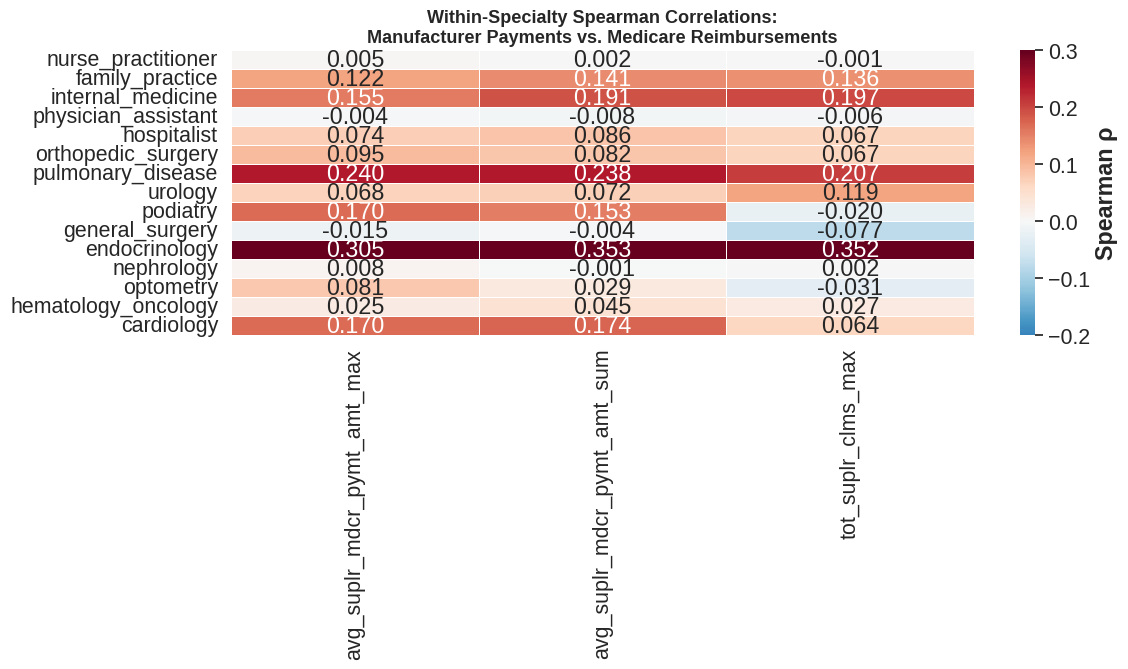


Specialties with significant (p<0.05) positive correlations for avg_suplr_mdcr_pymt_amt_sum:
  endocrinology                   ρ = +0.353  (n=2,014, p=4.6405e-60)
  pulmonary_disease               ρ = +0.238  (n=3,838, p=2.2295e-50)
  internal_medicine               ρ = +0.191  (n=24,076, p=8.8903e-197)
  cardiology                      ρ = +0.174  (n=1,502, p=1.1797e-11)
  podiatry                        ρ = +0.153  (n=2,383, p=6.9244e-14)
  family_practice                 ρ = +0.141  (n=30,765, p=3.4936e-137)
  hospitalist                     ρ = +0.086  (n=4,724, p=3.1577e-09)
  orthopedic_surgery              ρ = +0.082  (n=4,512, p=3.1455e-08)
  urology                         ρ = +0.072  (n=2,925, p=1.0433e-04)


In [16]:
#  Within-specialty Spearman correlations 

spec_corrs = []
for spec in top_spec_names:
    subset = df[df['og_specialty_name'] == spec]
    if len(subset) < 30:
        continue
    for outcome in OUTCOMES:
        rho, p = stats.spearmanr(subset[EXPOSURE], subset[outcome])
        spec_corrs.append({
            'specialty': spec,
            'outcome': outcome,
            'n': len(subset),
            'spearman_rho': rho,
            'p_value': p,
            'significant': p < 0.05
        })

spec_corr_df = pd.DataFrame(spec_corrs)

# Pivot for display
pivot = spec_corr_df.pivot(index='specialty', columns='outcome', values='spearman_rho')
pivot = pivot.loc[top_spec_names]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-0.2, vmax=0.3, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Within-Specialty Spearman Correlations:\nManufacturer Payments vs. Medicare Reimbursements',
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print(f'\nSpecialties with significant (p<0.05) positive correlations for avg_suplr_mdcr_pymt_amt_sum:')
sig = spec_corr_df[
    (spec_corr_df['outcome'] == 'avg_suplr_mdcr_pymt_amt_sum') &
    (spec_corr_df['significant']) &
    (spec_corr_df['spearman_rho'] > 0)
].sort_values('spearman_rho', ascending=False)
for _, row in sig.iterrows():
    print(f"  {row['specialty']:30s}  ρ = {row['spearman_rho']:+.3f}  (n={row['n']:,}, p={row['p_value']:.4e})")

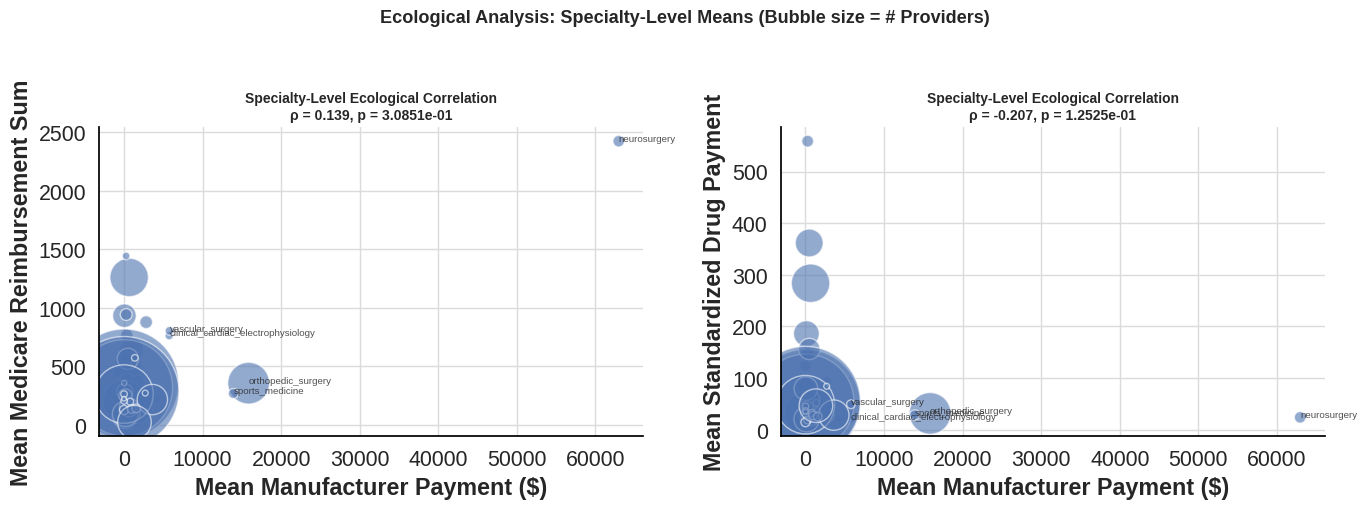


Caution: Ecological correlations should not be interpreted at the individual level (ecological fallacy). They provide complementary, not confirmatory, evidence.


In [17]:
######################################################################
# SPECIALTY SCATTER PLOTS: mean payment vs mean reimbursement 
######################################################################
# Ecological (aggregate) correlation to complement individual-level analysis

spec_agg = df.groupby('og_specialty_name').agg(
    mean_payment=(EXPOSURE, 'mean'),
    mean_reimb=('avg_suplr_mdcr_pymt_amt_sum', 'mean'),
    mean_drug_pymt=('tot_suplr_clms_max', 'mean'),
    n_providers=('npi', 'count')
).reset_index()
spec_agg = spec_agg[spec_agg['n_providers'] >= 50]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (y_col, ylabel) in enumerate([
    ('mean_reimb', 'Mean Medicare Reimbursement Sum'),
    ('mean_drug_pymt', 'Mean Standardized Drug Payment')
]):
    ax = axes[i]
    ax.scatter(spec_agg['mean_payment'], spec_agg[y_col],
              s=spec_agg['n_providers']/5, alpha=0.6, color='#4C72B0', edgecolors='white')
    
    # Annotate top specialties
    for _, row in spec_agg.nlargest(5, 'mean_payment').iterrows():
        ax.annotate(row['og_specialty_name'], (row['mean_payment'], row[y_col]),
                    fontsize=7, alpha=0.8, ha='left')
    
    rho, p = stats.spearmanr(spec_agg['mean_payment'], spec_agg[y_col])
    ax.set_xlabel('Mean Manufacturer Payment ($)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Specialty-Level Ecological Correlation\nρ = {rho:.3f}, p = {p:.4e}', fontsize=10)

fig.suptitle('Ecological Analysis: Specialty-Level Means (Bubble size = # Providers)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('\nCaution: Ecological correlations should not be interpreted at the individual level '
      '(ecological fallacy). They provide complementary, not confirmatory, evidence.')

### Specialty Type (Credential-Level) Analysis

The specialty_type variable captures the provider's credential category (e.g., Medical Doctor, Doctor of Osteopathy, Other). This is a coarser grouping than individual specialty and reflects differences in training pipelines, prescribing authority, and typical practice patterns — all of which may moderate the payment-reimbursement relationship.

In [18]:
######################################################################
# SPECIALTY TYPE VIZES
######################################################################

spec_type_summary = df.groupby('specialty_type').agg(
    n_providers=('npi', 'count'),
    pct_received_payment=('received_payment', 'mean'),
    mean_payment=(EXPOSURE, 'mean'),
    median_payment=(EXPOSURE, 'median'),
    mean_reimb=('avg_suplr_mdcr_pymt_amt_sum', 'mean'),
    median_reimb=('avg_suplr_mdcr_pymt_amt_sum', 'median'),
    mean_drug_pymt=('tot_suplr_clms_max', 'mean'),
    mean_risk_score=('bene_avg_risk_scre', 'mean')
).round(2)
spec_type_summary['pct_received_payment'] = (spec_type_summary['pct_received_payment'] * 100).round(1)

print(' Provider Profile by Specialty Type (Credential) ')
print(spec_type_summary.to_string())
print(f'\nTotal providers: {len(df):,}')

 Provider Profile by Specialty Type (Credential) 
                              n_providers  pct_received_payment  mean_payment  median_payment  mean_reimb  median_reimb  mean_drug_pymt  mean_risk_score
specialty_type                                                                                                                                          
Doctor of Dentistry                     3                 100.0        746.39           13.52        5.51          6.01           12.00             2.10
Doctor of Optometry                  1671                  59.0        152.06           18.48       94.39         94.06           20.47             0.99
Doctor of Osteopathy                30870                  33.0         25.79            0.00      353.67        210.39           49.85             1.72
Doctor of Podiatric Medicine         2383                  79.0       3612.71          150.18      216.41        125.98           28.28             1.73
Medical Doctor                  

In [19]:
#  Within-specialty-type Spearman correlations 

print(' Spearman ρ: Manufacturer Payment vs. Medicare Reimbursement, by Specialty Type ')
print('=' * 95)

stype_corrs = []
for stype, grp in df.groupby('specialty_type'):
    if len(grp) < 30:
        continue
    for outcome in OUTCOMES:
        rho, p = stats.spearmanr(grp[EXPOSURE], grp[outcome])
        stype_corrs.append({
            'specialty_type': stype,
            'outcome': outcome,
            'n': len(grp),
            'spearman_rho': rho,
            'p_value': p,
            'significant_05': p < 0.05
        })

stype_corr_df = pd.DataFrame(stype_corrs)

for outcome in OUTCOMES:
    print(f'\n  Outcome: {outcome}')
    sub = stype_corr_df[stype_corr_df['outcome'] == outcome].sort_values('spearman_rho', ascending=False)
    for _, row in sub.iterrows():
        sig_marker = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 else ('*' if row['p_value'] < 0.05 else ''))
        print(f"    {row['specialty_type']:35s}  ρ = {row['spearman_rho']:+.4f}  (n={row['n']:>6,}, p={row['p_value']:.4e}) {sig_marker}")

 Spearman ρ: Manufacturer Payment vs. Medicare Reimbursement, by Specialty Type 

  Outcome: avg_suplr_mdcr_pymt_amt_sum
    Doctor of Podiatric Medicine         ρ = +0.1526  (n= 2,383, p=6.9244e-14) ***
    Doctor of Osteopathy                 ρ = +0.1415  (n=30,870, p=8.9042e-138) ***
    Medical Doctor                       ρ = +0.0540  (n=64,975, p=3.7302e-43) ***
    Doctor of Optometry                  ρ = +0.0290  (n= 1,671, p=2.3595e-01) 
    Other                                ρ = -0.0028  (n=40,925, p=5.7514e-01) 

  Outcome: tot_suplr_clms_max
    Doctor of Osteopathy                 ρ = +0.1363  (n=30,870, p=5.8577e-128) ***
    Medical Doctor                       ρ = +0.0649  (n=64,975, p=1.3361e-61) ***
    Other                                ρ = -0.0112  (n=40,925, p=2.3705e-02) *
    Doctor of Podiatric Medicine         ρ = -0.0204  (n= 2,383, p=3.1912e-01) 
    Doctor of Optometry                  ρ = -0.0314  (n= 1,671, p=1.9943e-01) 

  Outcome: avg_suplr_mdcr_pym

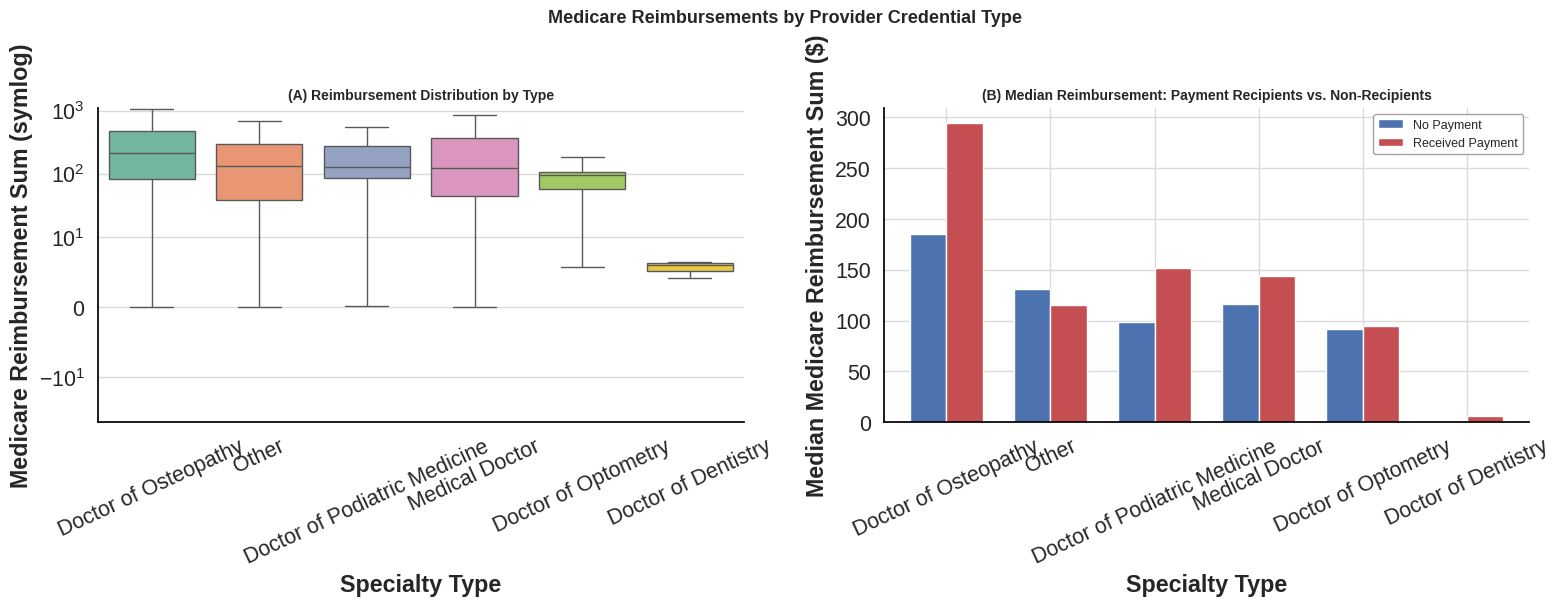

In [20]:
#  Visual: Reimbursement distributions by specialty type and payment receipt 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Box plots of reimbursement by specialty_type
ax = axes[0]
order = spec_type_summary.sort_values('median_reimb', ascending=False).index.tolist()
sns.boxplot(data=df, x='specialty_type', y='avg_suplr_mdcr_pymt_amt_sum',
            order=order, showfliers=False, palette='Set2', ax=ax)
ax.set_yscale('symlog', linthresh=10)
ax.set_xlabel('Specialty Type')
ax.set_ylabel('Medicare Reimbursement Sum (symlog)')
ax.set_title('(A) Reimbursement Distribution by Type', fontsize=10)
ax.tick_params(axis='x', rotation=25)

# Panel B: Median reimbursement split by payment receipt within each specialty type
ax = axes[1]
stype_pay_split = df.groupby(['specialty_type', 'received_payment']).agg(
    median_reimb=('avg_suplr_mdcr_pymt_amt_sum', 'median')
).reset_index()
stype_pay_split['received_payment'] = stype_pay_split['received_payment'].map({0: 'No Payment', 1: 'Received Payment'})

pivot_bar = stype_pay_split.pivot(index='specialty_type', columns='received_payment', values='median_reimb')
pivot_bar = pivot_bar.loc[order]
pivot_bar.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'], edgecolor='white', width=0.7)
ax.set_ylabel('Median Medicare Reimbursement Sum ($)')
ax.set_xlabel('Specialty Type')
ax.set_title('(B) Median Reimbursement: Payment Recipients vs. Non-Recipients', fontsize=10)
ax.tick_params(axis='x', rotation=25)
ax.legend(title='', fontsize=9)

fig.suptitle('Medicare Reimbursements by Provider Credential Type',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

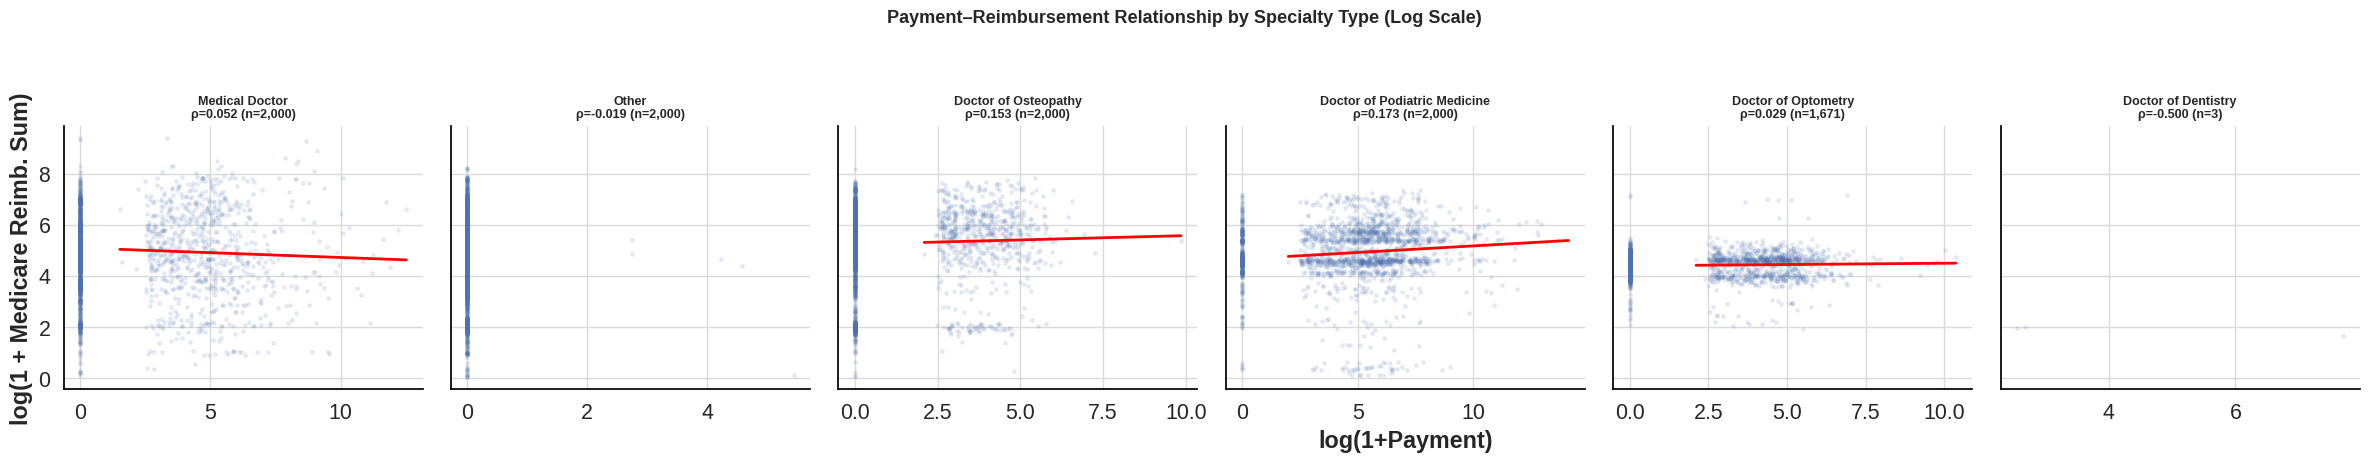

In [21]:
#  Scatter: log(payment) vs log(reimbursement) faceted by specialty_type 

stypes = df['specialty_type'].value_counts().index.tolist()
n_types = len(stypes)
fig, axes = plt.subplots(1, n_types, figsize=(4 * n_types, 4.5), sharey=True)

for i, stype in enumerate(stypes):
    ax = axes[i]
    sub = df[df['specialty_type'] == stype].sample(n=min(2000, (df['specialty_type']==stype).sum()), random_state=SEED)
    ax.scatter(sub['log_total_payment'], sub['log_mdcr_pymt_sum'],
               alpha=0.1, s=6, color='#4C72B0', rasterized=True)
    
    # Fit line for those with payments
    mask_pos = sub['log_total_payment'] > 0
    if mask_pos.sum() > 50:
        z = np.polyfit(sub.loc[mask_pos, 'log_total_payment'], sub.loc[mask_pos, 'log_mdcr_pymt_sum'], 1)
        xr = np.linspace(sub.loc[mask_pos, 'log_total_payment'].min(), sub.loc[mask_pos, 'log_total_payment'].max(), 50)
        ax.plot(xr, np.poly1d(z)(xr), color='red', linewidth=2)
    
    rho, p = stats.spearmanr(sub[EXPOSURE], sub['avg_suplr_mdcr_pymt_amt_sum'])
    ax.set_title(f'{stype}\nρ={rho:.3f} (n={len(sub):,})', fontsize=9)
    ax.set_xlabel('log(1+Payment)' if i == n_types//2 else '')
    if i == 0:
        ax.set_ylabel('log(1 + Medicare Reimb. Sum)')

fig.suptitle('Payment–Reimbursement Relationship by Specialty Type (Log Scale)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

### Granular Specialty Analysis

Payment–reimbursement association at the granular specialty level. This allows us to identify which specific specialties drive the aggregate association and whether certain high-reimbursement specialties show disproportionately strong payment effects.

In [22]:
######################################################################
# Ranked Spearman correlations by individual specialty 
######################################################################  

MIN_N = 50 # Restrict to specialties with n >= 50 for stable estimates
specialty_counts = df['specialty'].value_counts()
valid_specs = specialty_counts[specialty_counts >= MIN_N].index.tolist()

ind_spec_corrs = []
for spec in valid_specs:
    sub = df[df['specialty'] == spec]
    for outcome in ['avg_suplr_mdcr_pymt_amt_sum', 'tot_suplr_clms_max']:
        rho, p = stats.spearmanr(sub[EXPOSURE], sub[outcome])
        ind_spec_corrs.append({
            'specialty': spec,
            'specialty_type': sub['specialty_type'].mode().iloc[0],
            'n': len(sub),
            'pct_receiving_payment': (sub['received_payment'].mean() * 100).round(1),
            'outcome': outcome,
            'spearman_rho': rho,
            'p_value': p
        })

ind_spec_df = pd.DataFrame(ind_spec_corrs)

# Focus on primary outcome
reimb_spec = ind_spec_df[ind_spec_df['outcome'] == 'avg_suplr_mdcr_pymt_amt_sum'].sort_values('spearman_rho', ascending=False)

print(f' Spearman ρ (Manufacturer Payment vs Medicare Reimb. Sum) by Specialty (n ≥ {MIN_N}) ')
print(f'Total qualifying specialties: {len(reimb_spec)}')
print('=' * 100)
print(f'{"Specialty":40s} {"Type":30s} {"n":>6s} {"% w/Pay":>8s} {"ρ":>8s} {"p-value":>12s}')
print('-' * 100)
for _, row in reimb_spec.iterrows():
    sig = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 else ('*' if row['p_value'] < 0.05 else ''))
    print(f"{row['specialty']:40s} {row['specialty_type']:30s} {row['n']:6,d} {row['pct_receiving_payment']:7.1f}% {row['spearman_rho']:+.4f} {row['p_value']:12.4e} {sig}")

 Spearman ρ (Manufacturer Payment vs Medicare Reimb. Sum) by Specialty (n ≥ 50) 
Total qualifying specialties: 55
Specialty                                Type                                n  % w/Pay        ρ      p-value
----------------------------------------------------------------------------------------------------
Endocrinology                            Medical Doctor                  2,014    58.2% +0.3527   4.6405e-60 ***
Interventional Pain Management           Medical Doctor                     86    77.9% +0.2657   1.3424e-02 *
Pulmonary Disease                        Medical Doctor                  3,838    51.1% +0.2376   2.2295e-50 ***
Pediatrics                               Medical Doctor                    460    20.7% +0.2371   2.6774e-07 ***
Critical Care                            Medical Doctor                    396    36.6% +0.2007   5.7524e-05 ***
Hospice and Palliative Care              Other                              64     6.2% +0.1999   1.1322e-01 
Ps

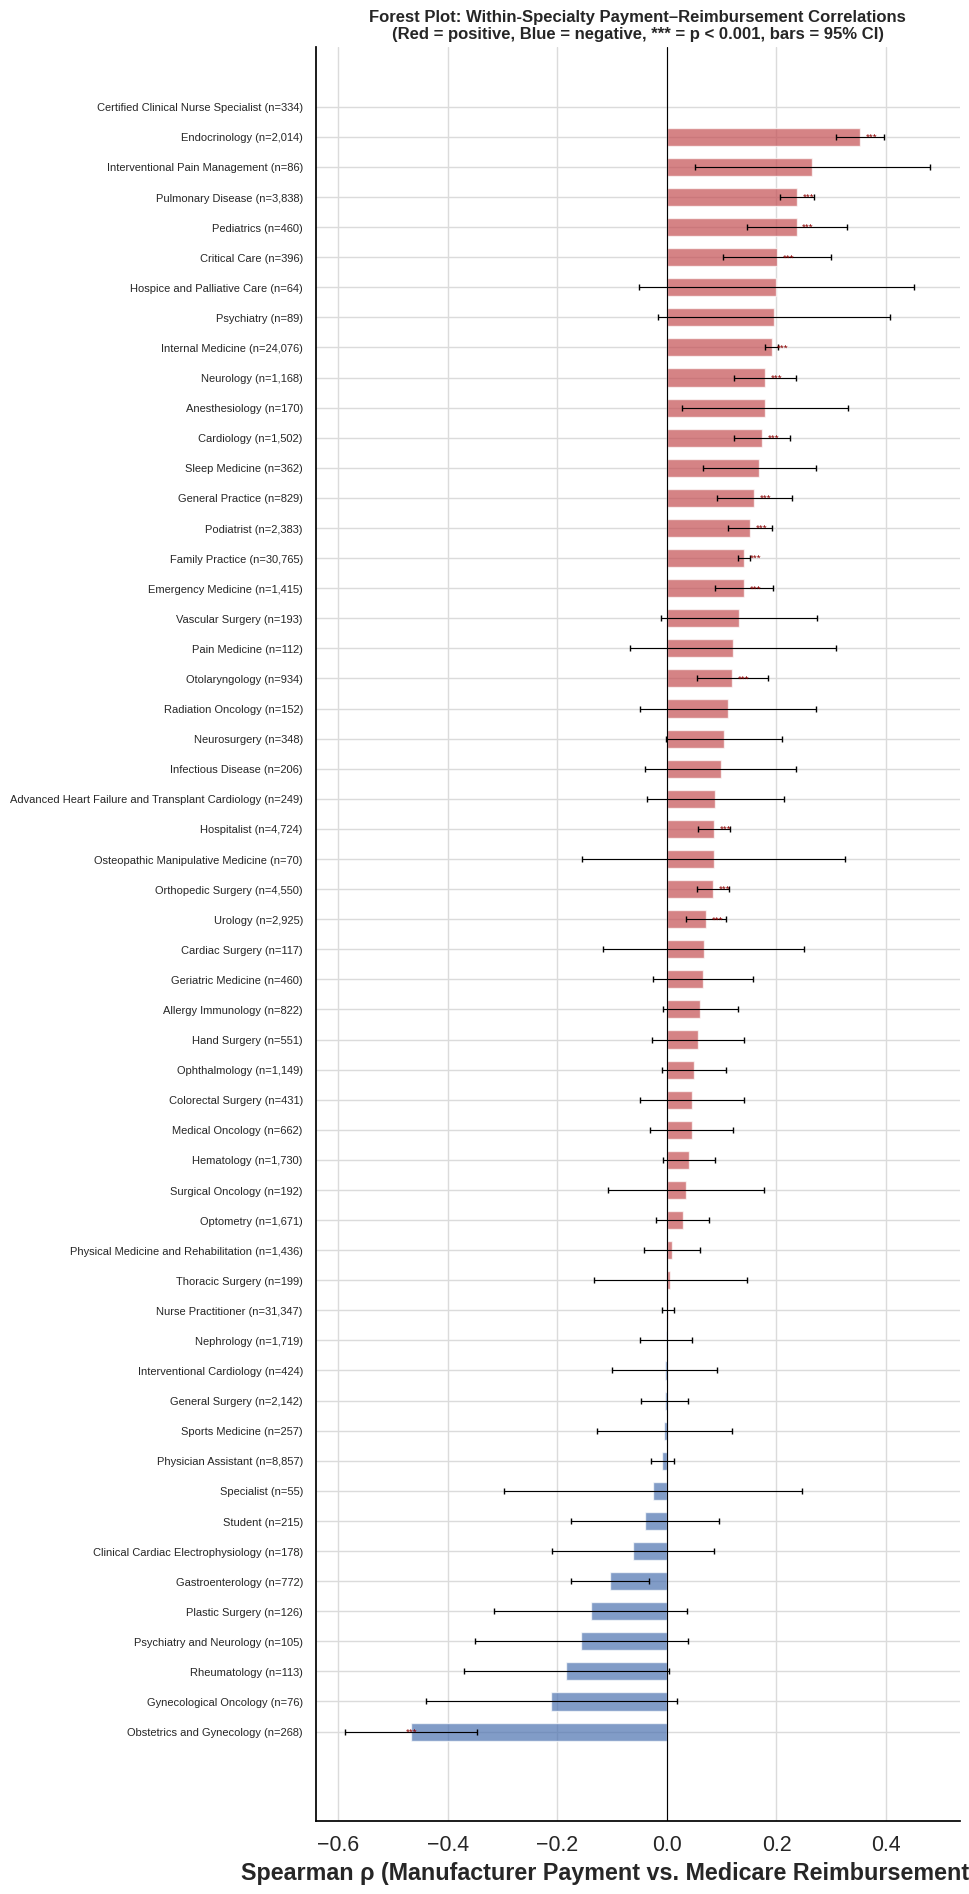


Significant positive correlations: 18/55
Significant negative correlations: 2/55


In [23]:
######################################################################
# FOREST PLOT
######################################################################  
plot_df = reimb_spec.copy()
# Approximate SE for Spearman rho: SE ≈ 1/sqrt(n-3)
plot_df['se'] = 1 / np.sqrt(plot_df['n'] - 3)
plot_df['ci_lo'] = plot_df['spearman_rho'] - 1.96 * plot_df['se']
plot_df['ci_hi'] = plot_df['spearman_rho'] + 1.96 * plot_df['se']
plot_df = plot_df.sort_values('spearman_rho', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.35)))

colors = plot_df['spearman_rho'].apply(
    lambda x: '#C44E52' if x > 0 else '#4C72B0'
)
y_pos = range(len(plot_df))

ax.barh(y_pos, plot_df['spearman_rho'], color=colors, alpha=0.7, height=0.6, edgecolor='white')
ax.errorbar(plot_df['spearman_rho'], y_pos, xerr=1.96 * plot_df['se'],
            fmt='none', color='black', capsize=2, linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')

# Significance markers
for j, (_, row) in enumerate(plot_df.iterrows()):
    if row['p_value'] < 0.001:
        ax.text(row['spearman_rho'] + 0.01 * (1 if row['spearman_rho'] >= 0 else -1),
                j, '***', fontsize=7, va='center', color='darkred')

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['specialty']} (n={row['n']:,})" for _, row in plot_df.iterrows()], fontsize=8)
ax.set_xlabel('Spearman ρ (Manufacturer Payment vs. Medicare Reimbursement Sum)')
ax.set_title('Forest Plot: Within-Specialty Payment–Reimbursement Correlations\n'
             '(Red = positive, Blue = negative, *** = p < 0.001, bars = 95% CI)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

n_pos_sig = ((reimb_spec['spearman_rho'] > 0) & (reimb_spec['p_value'] < 0.05)).sum()
n_neg_sig = ((reimb_spec['spearman_rho'] < 0) & (reimb_spec['p_value'] < 0.05)).sum()
print(f'\nSignificant positive correlations: {n_pos_sig}/{len(reimb_spec)}')
print(f'Significant negative correlations: {n_neg_sig}/{len(reimb_spec)}')

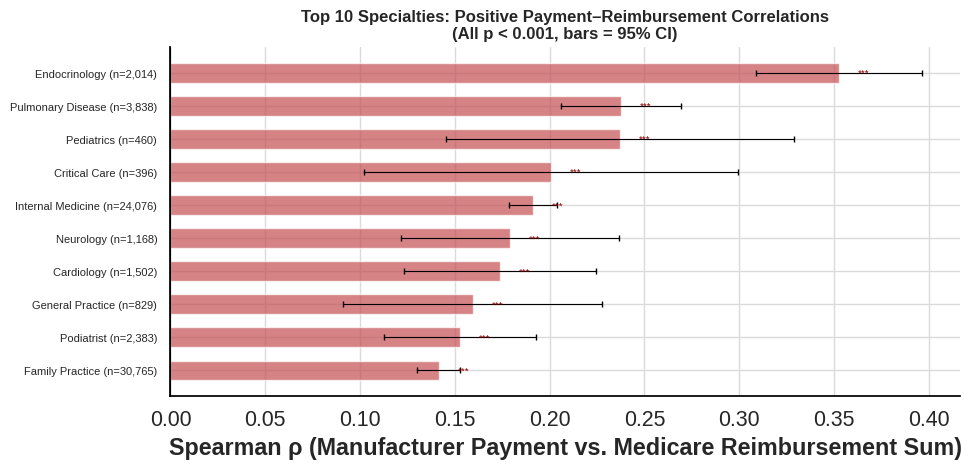


Showing top 10 of 15 specialties with significant positive correlations (p < 0.001)


In [24]:
######################################################################
# FOREST PLOT — Top 10 significant positive correlations (p < 0.001)
######################################################################
plot_df = reimb_spec.copy()

# Filter to positive correlations with p < 0.001, then take top 10
plot_df = plot_df[(plot_df['spearman_rho'] > 0) & (plot_df['p_value'] < 0.001)]
plot_df = plot_df.nlargest(10, 'spearman_rho')

# Approximate SE for Spearman rho: SE ≈ 1/sqrt(n-3)
plot_df['se'] = 1 / np.sqrt(plot_df['n'] - 3)
plot_df['ci_lo'] = plot_df['spearman_rho'] - 1.96 * plot_df['se']
plot_df['ci_hi'] = plot_df['spearman_rho'] + 1.96 * plot_df['se']
plot_df = plot_df.sort_values('spearman_rho', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = '#C44E52'
y_pos = range(len(plot_df))
ax.barh(y_pos, plot_df['spearman_rho'], color=colors, alpha=0.7, height=0.6, edgecolor='white')
ax.errorbar(plot_df['spearman_rho'], y_pos, xerr=1.96 * plot_df['se'],
            fmt='none', color='black', capsize=2, linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')

# Significance markers
for j, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row['spearman_rho'] + 0.01, j, '***', fontsize=7, va='center', color='darkred')

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['specialty']} (n={row['n']:,})" for _, row in plot_df.iterrows()], fontsize=8)
ax.set_xlabel('Spearman ρ (Manufacturer Payment vs. Medicare Reimbursement Sum)')
ax.set_title('Top 10 Specialties: Positive Payment–Reimbursement Correlations\n'
             '(All p < 0.001, bars = 95% CI)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nShowing top 10 of {((reimb_spec["spearman_rho"] > 0) & (reimb_spec["p_value"] < 0.001)).sum()} '
      f'specialties with significant positive correlations (p < 0.001)')

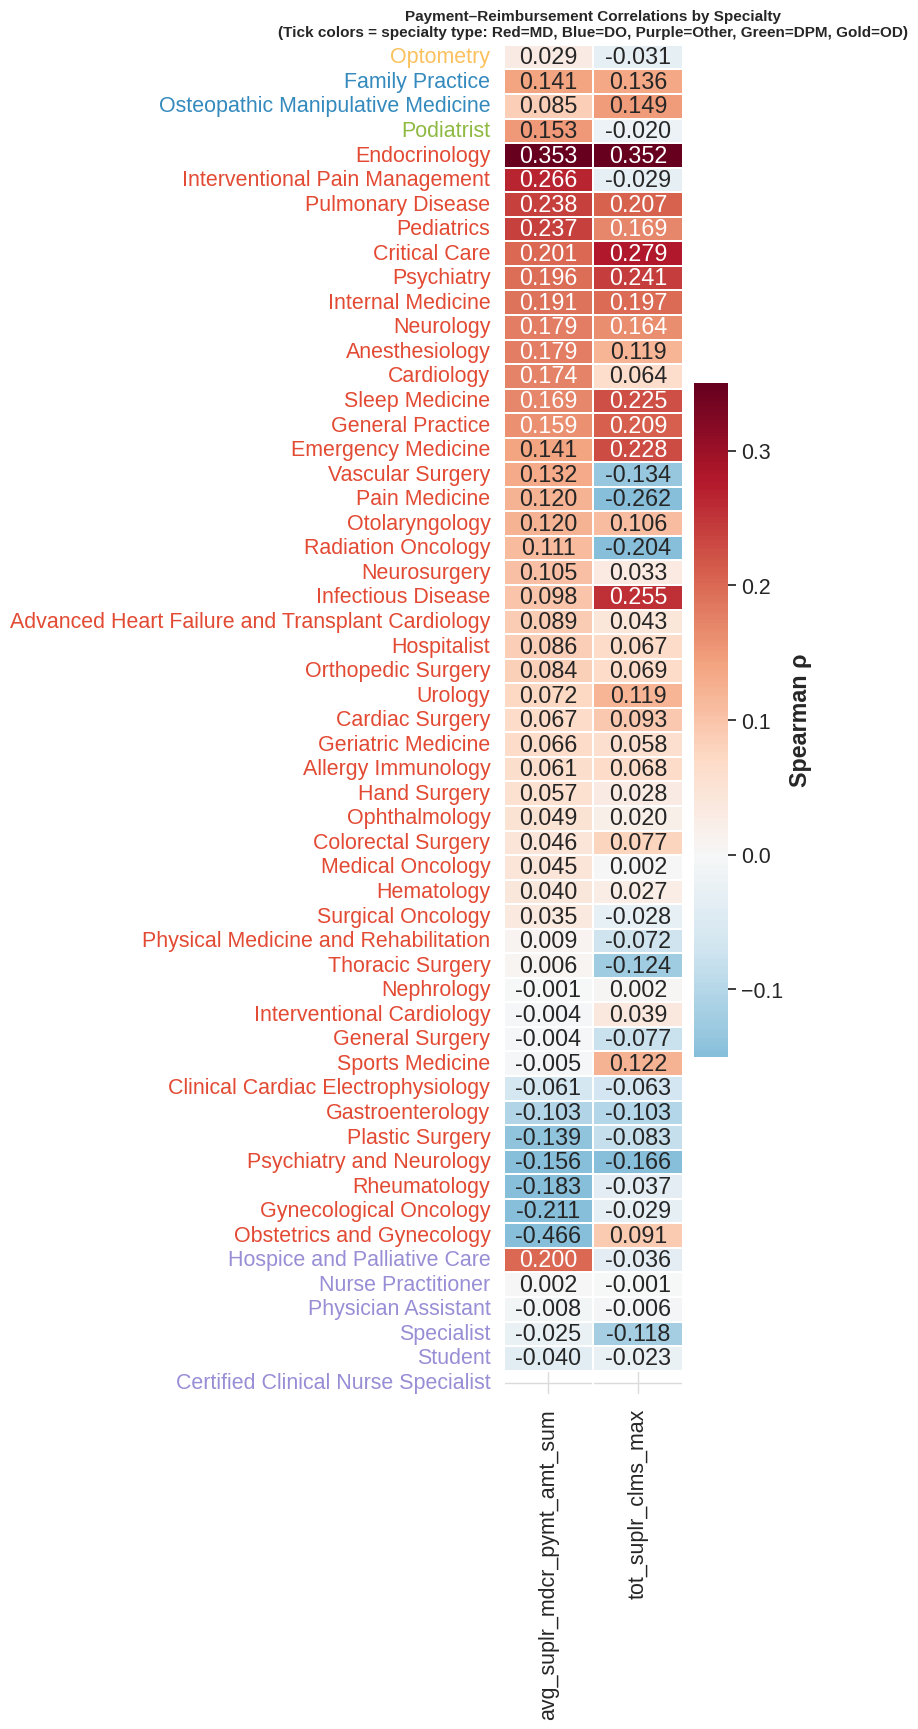

In [25]:
#  Heatmap: specialty × outcome correlations, ordered by specialty_type 

heat_df = ind_spec_df.pivot(index='specialty', columns='outcome', values='spearman_rho')

# Add specialty_type for ordering
type_map = ind_spec_df[['specialty', 'specialty_type']].drop_duplicates().set_index('specialty')['specialty_type']
heat_df['specialty_type'] = heat_df.index.map(type_map)
heat_df = heat_df.sort_values(['specialty_type', 'avg_suplr_mdcr_pymt_amt_sum'], ascending=[True, False])
stype_labels = heat_df['specialty_type']
heat_df = heat_df.drop(columns='specialty_type')

fig, ax = plt.subplots(figsize=(8, max(6, len(heat_df) * 0.32)))
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-0.15, vmax=0.35, linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Spearman ρ', 'shrink': 0.6})

# Add specialty_type color sidebar via colored tick labels
type_colors = {'Medical Doctor': '#E24A33', 'Doctor of Osteopathy': '#348ABD',
               'Other': '#988ED5', 'Doctor of Podiatric Medicine': '#8EBA42',
               'Doctor of Optometry': '#FBC15E'}
for tick_label in ax.get_yticklabels():
    spec_name = tick_label.get_text()
    stype = type_map.get(spec_name, 'Other')
    tick_label.set_color(type_colors.get(stype, 'black'))

ax.set_title('Payment–Reimbursement Correlations by Specialty\n'
             '(Tick colors = specialty type: Red=MD, Blue=DO, Purple=Other, Green=DPM, Gold=OD)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [26]:
######################################################################
# Formal interaction test: does specialty_type moderate the payment effect? 
######################################################################  #

# Compare nested models with and without interaction terms
from sklearn.linear_model import LinearRegression

# Create interaction terms: log_payment × specialty_type dummies
stype_dums = pd.get_dummies(df['specialty_type'], prefix='stype', drop_first=True).astype(float)
interaction_terms = stype_dums.multiply(df['log_total_payment'], axis=0)
interaction_terms.columns = [c + '_x_logpay' for c in interaction_terms.columns]

# Base model: log_reimb ~ log_payment + specialty_type dummies + confounders
base_features = ['log_total_payment'] + CONFOUNDERS
base_X = pd.concat([df[base_features], stype_dums], axis=1).apply(pd.to_numeric, errors='coerce').dropna()
common_idx = base_X.index.intersection(interaction_terms.dropna().index)

base_X = base_X.loc[common_idx]
inter_X = pd.concat([base_X, interaction_terms.loc[common_idx]], axis=1)
y_inter = df.loc[common_idx, 'log_mdcr_pymt_sum'].values

# Fit both models
model_base = LinearRegression().fit(base_X.values.astype(float), y_inter)
model_inter = LinearRegression().fit(inter_X.values.astype(float), y_inter)

rss_base = np.sum((y_inter - model_base.predict(base_X.values.astype(float))) ** 2)
rss_inter = np.sum((y_inter - model_inter.predict(inter_X.values.astype(float))) ** 2)

n_obs = len(y_inter)
p_base = base_X.shape[1]
p_inter = inter_X.shape[1]
df_diff = p_inter - p_base

# Partial F-test for interaction terms
f_stat = ((rss_base - rss_inter) / df_diff) / (rss_inter / (n_obs - p_inter - 1))
f_p_value = 1 - stats.f.cdf(f_stat, df_diff, n_obs - p_inter - 1)

print(' Interaction Test: Does Specialty Type Moderate the Payment–Reimbursement Relationship? ')
print(f'Base model features: {p_base}, Interaction model features: {p_inter}')
print(f'Additional interaction parameters: {df_diff}')
print(f'\nPartial F-test: F({df_diff}, {n_obs - p_inter - 1}) = {f_stat:.3f}, p = {f_p_value:.4e}')
if f_p_value < 0.05:
    print('→ The interaction is statistically significant: the payment–reimbursement')
    print('  association differs across specialty types. This supports specialty-stratified modeling.')
else:
    print('→ The interaction is NOT significant: the payment–reimbursement association')
    print('  does not vary meaningfully by specialty type.')

# Show the interaction coefficients
inter_coefs = pd.Series(model_inter.coef_, index=inter_X.columns)
print('\nInteraction coefficients (how slope differs from reference group):')
for col in interaction_terms.columns:
    coef = inter_coefs[col]
    print(f'  {col:45s}  β = {coef:+.4f}')
print(f'  {"log_total_payment (reference group)":45s}  β = {inter_coefs["log_total_payment"]:+.4f}')

 Interaction Test: Does Specialty Type Moderate the Payment–Reimbursement Relationship? 
Base model features: 15, Interaction model features: 20
Additional interaction parameters: 5

Partial F-test: F(5, 140806) = 10.225, p = 8.1834e-10
→ The interaction is statistically significant: the payment–reimbursement
  association differs across specialty types. This supports specialty-stratified modeling.

Interaction coefficients (how slope differs from reference group):
  stype_Doctor of Optometry_x_logpay             β = +0.0262
  stype_Doctor of Osteopathy_x_logpay            β = +0.0425
  stype_Doctor of Podiatric Medicine_x_logpay    β = +0.0587
  stype_Medical Doctor_x_logpay                  β = +0.0685
  stype_Other_x_logpay                           β = +0.0273
  log_total_payment (reference group)            β = -0.0243


In [27]:
#  Specialty-level "payment gap" analysis 
# For each specialty: how much higher is the median reimbursement for
# payment recipients vs non-recipients? (adjusted for sample size)

gap_results = []
for spec in valid_specs:
    sub = df[df['specialty'] == spec]
    pay_yes = sub[sub['received_payment'] == 1]['avg_suplr_mdcr_pymt_amt_sum']
    pay_no = sub[sub['received_payment'] == 0]['avg_suplr_mdcr_pymt_amt_sum']
    
    if len(pay_yes) < 10 or len(pay_no) < 10:
        continue
    
    stat, p = stats.mannwhitneyu(pay_yes, pay_no, alternative='two-sided')
    med_diff = pay_yes.median() - pay_no.median()
    pct_diff = (med_diff / pay_no.median() * 100) if pay_no.median() > 0 else np.nan
    
    gap_results.append({
        'specialty': spec,
        'specialty_type': sub['specialty_type'].mode().iloc[0],
        'n_with_pay': len(pay_yes),
        'n_without_pay': len(pay_no),
        'median_reimb_with_pay': pay_yes.median(),
        'median_reimb_no_pay': pay_no.median(),
        'median_diff': med_diff,
        'pct_diff': pct_diff,
        'mw_p_value': p
    })

gap_df = pd.DataFrame(gap_results).sort_values('pct_diff', ascending=False)

print(' Reimbursement Gap: Payment Recipients vs. Non-Recipients by Specialty ')
print(f'{"Specialty":35s} {"Type":20s} {"Med w/":>10s} {"Med w/o":>10s} {"Δ%":>8s} {"p-value":>12s}')
print('-' * 100)
for _, row in gap_df.iterrows():
    sig = '*' if row['mw_p_value'] < 0.05 else ''
    print(f"{row['specialty']:35s} {row['specialty_type']:20s} ${row['median_reimb_with_pay']:>9,.0f} ${row['median_reimb_no_pay']:>9,.0f} {row['pct_diff']:>+7.1f}% {row['mw_p_value']:12.4e} {sig}")

 Reimbursement Gap: Payment Recipients vs. Non-Recipients by Specialty 
Specialty                           Type                     Med w/    Med w/o       Δ%      p-value
----------------------------------------------------------------------------------------------------
Psychiatry                          Medical Doctor       $      333 $       68  +391.3%   1.0597e-01 
Critical Care                       Medical Doctor       $    1,082 $      350  +208.8%   6.8731e-07 *
Pediatrics                          Medical Doctor       $      201 $       74  +172.3%   7.2617e-07 *
Interventional Pain Management      Medical Doctor       $      484 $      184  +163.5%   1.5995e-01 
Endocrinology                       Medical Doctor       $      552 $      225  +144.8%   3.5679e-47 *
Internal Medicine                   Medical Doctor       $      264 $      129  +104.2%  1.2146e-188 *
General Practice                    Medical Doctor       $      308 $      161   +91.1%   1.4276e-06 *
Infecti

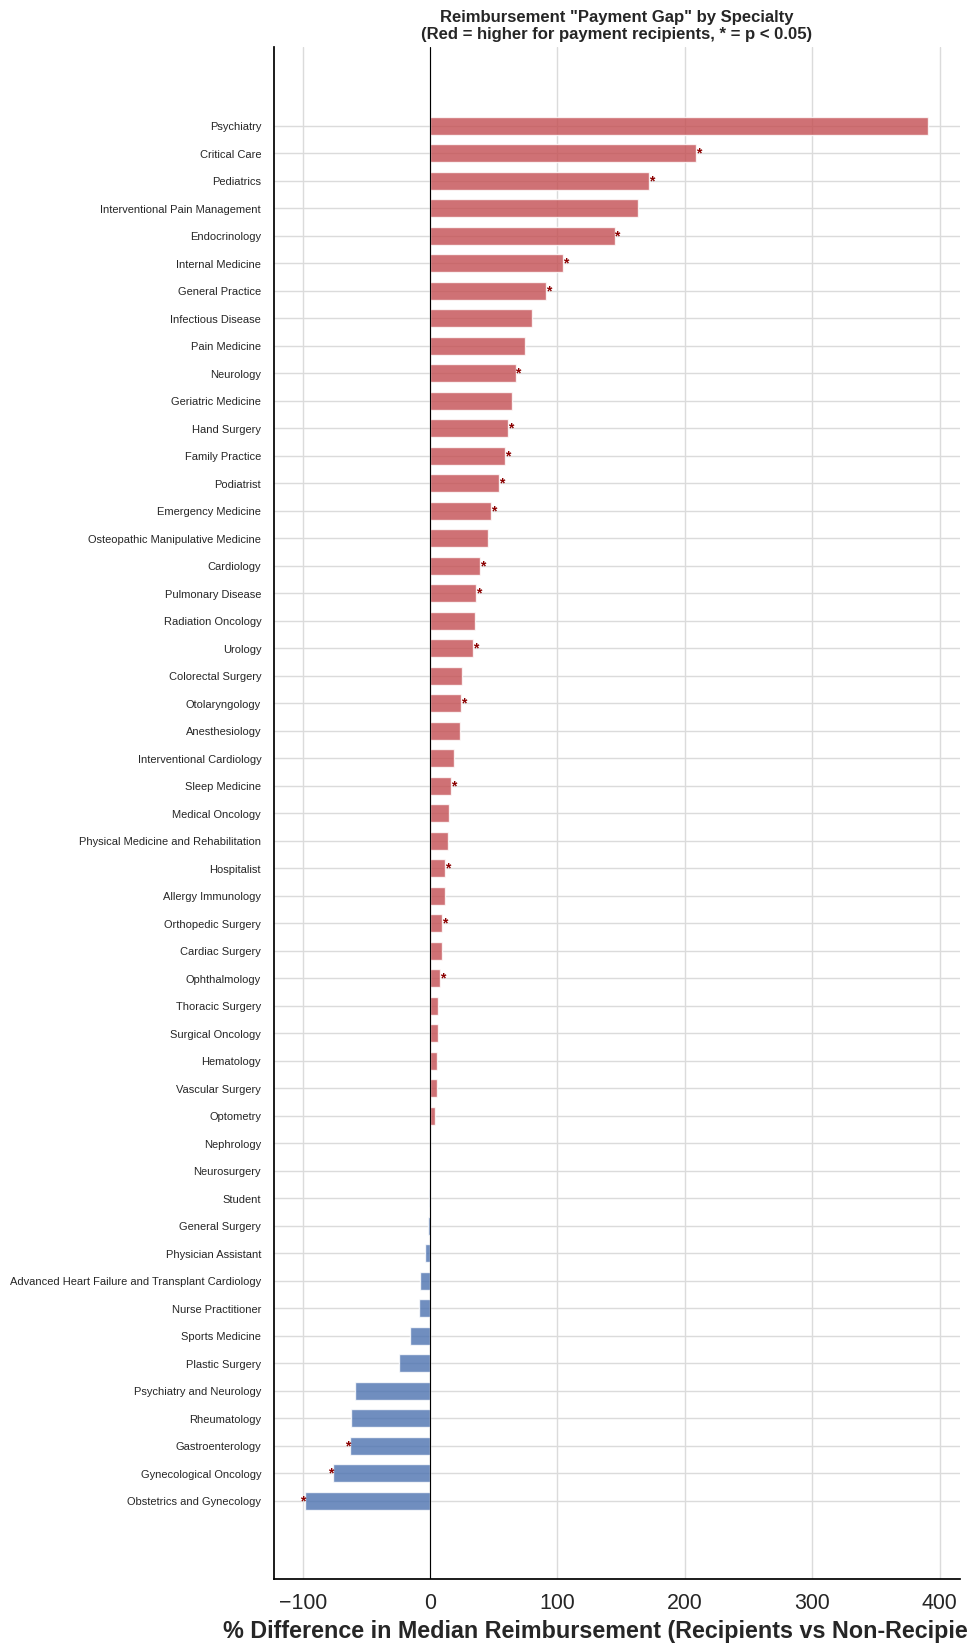


Specialties where payment recipients have significantly higher reimbursements:
  18/51 specialties (35%)
  Largest gaps: Critical Care, Pediatrics, Endocrinology


In [28]:
#  Diverging bar chart: % reimbursement gap by specialty 

plot_gap = gap_df.dropna(subset=['pct_diff']).sort_values('pct_diff', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_gap) * 0.33)))

colors = ['#C44E52' if x > 0 else '#4C72B0' for x in plot_gap['pct_diff']]
bars = ax.barh(range(len(plot_gap)), plot_gap['pct_diff'], color=colors, alpha=0.8,
               edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=0.8)

# Mark significant specialties
for j, (_, row) in enumerate(plot_gap.iterrows()):
    if row['mw_p_value'] < 0.05:
        ax.text(row['pct_diff'] + (2 if row['pct_diff'] >= 0 else -2), j,
                '*', fontsize=10, va='center', ha='center', color='darkred', fontweight='bold')

ax.set_yticks(range(len(plot_gap)))
ax.set_yticklabels([f"{row['specialty']}" for _, row in plot_gap.iterrows()], fontsize=8)
ax.set_xlabel('% Difference in Median Reimbursement (Recipients vs Non-Recipients)')
ax.set_title('Reimbursement "Payment Gap" by Specialty\n'
             '(Red = higher for payment recipients, * = p < 0.05)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nSpecialties where payment recipients have significantly higher reimbursements:')
sig_gap = gap_df[(gap_df['pct_diff'] > 0) & (gap_df['mw_p_value'] < 0.05)]
print(f'  {len(sig_gap)}/{len(gap_df)} specialties ({len(sig_gap)/len(gap_df)*100:.0f}%)')
print(f'  Largest gaps: {", ".join(sig_gap.head(3)["specialty"].tolist())}')

## Payment Type Decomposition

Not all manufacturer payments are equivalent. Use payment categories (food/beverage, consulting/speaking, ownership) to assess which types drive the association.

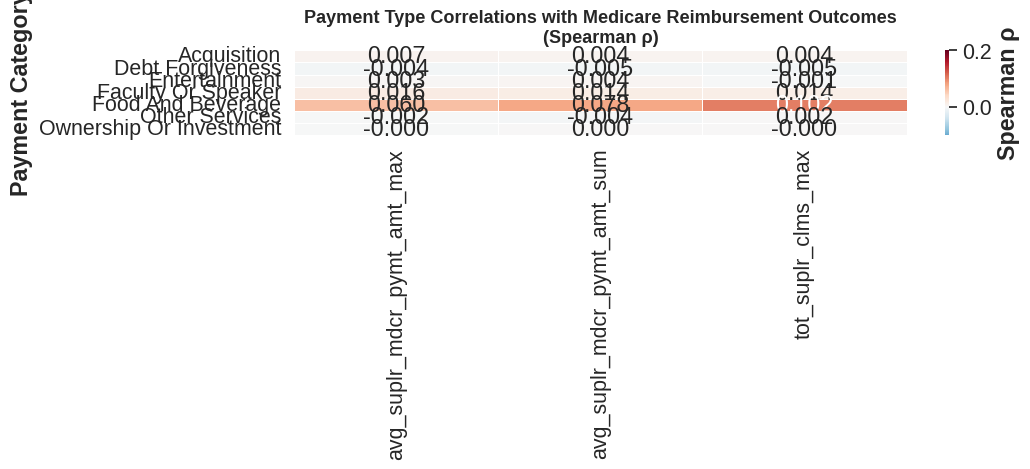


Interpretation: Payments for consulting, speaking, and ownership interests may show
stronger associations than food/beverage, consistent with dose-response expectations.


In [29]:
#  Correlation of each payment type with reimbursement outcomes 

nature_corrs = []
for col in PAYMENT_NATURE_COLS:
    for outcome in OUTCOMES:
        rho, p = stats.spearmanr(df[col], df[outcome])
        nature_corrs.append({
            'payment_type': col.replace('nature_sum_', '').replace('_', ' ').title(),
            'outcome': outcome,
            'spearman_rho': rho,
            'p_value': p
        })

nature_corr_df = pd.DataFrame(nature_corrs)
pivot_nature = nature_corr_df.pivot(index='payment_type', columns='outcome', values='spearman_rho')

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot_nature, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-0.1, vmax=0.2, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Payment Type Correlations with Medicare Reimbursement Outcomes\n(Spearman ρ)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Payment Category')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print('\nInterpretation: Payments for consulting, speaking, and ownership interests may show')
print('stronger associations than food/beverage, consistent with dose-response expectations.')

## Multivariable Regression Analysis

To assess whether the association between manufacturer payments and Medicare reimbursements persists after adjusting for confounders, fit OLS regression models on log-transformed variables. Using a hierarchical approach:

- Model 1 (Unadjusted): log(reimbursement) ~ log(payment)
- Model 2 (+ Practice characteristics): Adds provider volume and service breadth
- Model 3 (+ Patient case-mix): Adds risk score, dual-eligible count, age concentration
- Model 4 (+ Specialty FE): Adds specialty fixed effects via dummy variables


In [30]:
#  Prepare regression data 

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Specialty dummies (top 15 + "other")
df['specialty_group'] = df['og_specialty_name'].where(
    df['og_specialty_name'].isin(top_spec_names), 'other'
)
spec_dummies = pd.get_dummies(df['specialty_group'], prefix='spec', drop_first=True)

# Analytical dataset
reg_cols = ['log_total_payment', 'log_mdcr_pymt_sum', 'log_mdcr_pymt_min'] + CONFOUNDERS

reg_df = pd.concat([df[reg_cols], spec_dummies], axis=1).dropna()
# Ensure all columns are numeric (booleans -> float)
reg_df = reg_df.apply(pd.to_numeric, errors='coerce').dropna()
print(f'Regression analytical sample: n = {len(reg_df):,}')
print(f'Specialty dummies: {spec_dummies.shape[1]} columns')

Regression analytical sample: n = 140,827
Specialty dummies: 15 columns


In [31]:
#  Hierarchical OLS Regression 

def run_ols(X, y, feature_names):
    """Fit OLS and return summary dict."""
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    # R-squared
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    n, p = X.shape
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    # Coefficient standard errors (OLS)
    mse = ss_res / (n - p - 1)
    try:
        var_coef = mse * np.linalg.inv(X.T @ X).diagonal()
        se = np.sqrt(np.abs(var_coef))
    except np.linalg.LinAlgError:
        se = np.full(p, np.nan)
    
    t_stats = model.coef_ / se
    p_values = 2 * stats.t.sf(np.abs(t_stats), df=n - p - 1)
    
    coef_df = pd.DataFrame({
        'coefficient': model.coef_,
        'std_error': se,
        't_stat': t_stats,
        'p_value': p_values
    }, index=feature_names)
    
    return {
        'model': model,
        'r2': r2,
        'adj_r2': adj_r2,
        'n': n,
        'p': p,
        'coef_df': coef_df,
        'intercept': model.intercept_
    }

# Define model specifications
OUTCOME_VAR = 'log_mdcr_pymt_sum'

# Referral structure confounders
referral_vars = [
                 'tot_suplr_nonrntl_hcpcs_cds', 'tot_suplr_rentl_hcpcs_cds', 'hi_risk_hcpcs']

# Patient case-mix confounders
casemix_vars = ['bene_avg_risk_scre', 'bene_cc_ph_diabetes_v2_pct', 'bene_cc_ph_copd_v2_pct',
                'elderly_patient_concentration', 'bene_dual_cnt', 'active_medicaid_provider_flag']

specs = {
    'Model 1: Unadjusted': ['log_total_payment'],
    'Model 2: + DMEPOS Referral': ['log_total_payment'] + referral_vars,
    'Model 3: + Case-Mix': ['log_total_payment'] + referral_vars + casemix_vars,
    'Model 4: + Specialty FE': ['log_total_payment'] + referral_vars + casemix_vars
                                + [c for c in spec_dummies.columns]
}

results = {}
y = reg_df[OUTCOME_VAR].values

print(f'Dependent Variable: {OUTCOME_VAR}')
print(f'Interpretation: coefficients represent elasticity (% change in reimbursement per % change in payment)')
print('-' * 80)

for name, features in specs.items():
    X = reg_df[features].values
    res = run_ols(X, y, features)
    results[name] = res
    
    # Extract key coefficient
    pay_coef = res['coef_df'].loc['log_total_payment']
    print(f'\n{name}')
    print(f'  n = {res["n"]:,}, R² = {res["r2"]:.4f}, Adj. R² = {res["adj_r2"]:.4f}')
    print(f'  log_total_payment: β = {pay_coef["coefficient"]:+.4f} (SE = {pay_coef["std_error"]:.4f}), '
          f't = {pay_coef["t_stat"]:.2f}, p = {pay_coef["p_value"]:.4e}')

print('\n' + '=' * 90)
print('\nKey finding: Track whether the coefficient on log_total_payment attenuates')
print('as confounders are added. Substantial attenuation suggests confounding by')
print('specialty and practice characteristics rather than a direct causal pathway.')

Dependent Variable: log_mdcr_pymt_sum
Interpretation: coefficients represent elasticity (% change in reimbursement per % change in payment)
--------------------------------------------------------------------------------

Model 1: Unadjusted
  n = 140,827, R² = 0.0043, Adj. R² = 0.0043
  log_total_payment: β = +0.0453 (SE = 0.0016), t = 28.29, p = 1.5478e-175

Model 2: + DMEPOS Referral
  n = 140,827, R² = 0.4027, Adj. R² = 0.4026
  log_total_payment: β = +0.0535 (SE = 0.0014), t = 39.38, p = 0.0000e+00

Model 3: + Case-Mix
  n = 140,827, R² = 0.4255, Adj. R² = 0.4255
  log_total_payment: β = +0.0415 (SE = 0.0014), t = 29.84, p = 5.5601e-195

Model 4: + Specialty FE
  n = 140,827, R² = 0.4699, Adj. R² = 0.4698
  log_total_payment: β = +0.0347 (SE = 0.0016), t = 21.75, p = 1.0097e-104


Key finding: Track whether the coefficient on log_total_payment attenuates
as confounders are added. Substantial attenuation suggests confounding by
specialty and practice characteristics rather than a d

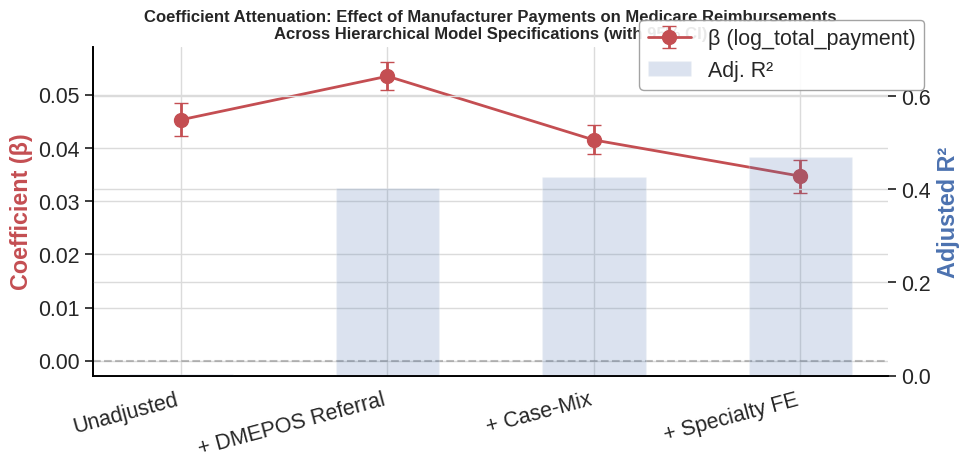


Coefficient attenuation from Model 1 to Model 4: -23.4%
Substantial attenuation (>10%) indicates meaningful confounding.


In [32]:
#  Coefficient attenuation plot 

model_names = list(results.keys())
betas = [results[m]['coef_df'].loc['log_total_payment', 'coefficient'] for m in model_names]
ses = [results[m]['coef_df'].loc['log_total_payment', 'std_error'] for m in model_names]
r2s = [results[m]['adj_r2'] for m in model_names]

fig, ax1 = plt.subplots(figsize=(10, 5))

x_pos = range(len(model_names))
ax1.errorbar(x_pos, betas, yerr=[1.96*s for s in ses], fmt='o-', color='#C44E52',
             markersize=10, capsize=5, linewidth=2, label='β (log_total_payment)')
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylabel('Coefficient (β)', color='#C44E52')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['Unadjusted', '+ DMEPOS Referral', '+ Case-Mix', '+ Specialty FE'],
                     rotation=15, ha='right')

ax2 = ax1.twinx()
ax2.bar(x_pos, r2s, alpha=0.2, color='#4C72B0', width=0.5, label='Adj. R²')
ax2.set_ylabel('Adjusted R²', color='#4C72B0')
ax2.set_ylim(0, max(r2s) * 1.5)

fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
ax1.set_title('Coefficient Attenuation: Effect of Manufacturer Payments on Medicare Reimbursements\n'
              'Across Hierarchical Model Specifications (with 95% CI)',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

pct_change = (betas[-1] - betas[0]) / abs(betas[0]) * 100
print(f'\nCoefficient attenuation from Model 1 to Model 4: {pct_change:+.1f}%')
if abs(pct_change) > 10:
    print('Substantial attenuation (>10%) indicates meaningful confounding.')
else:
    print('Minimal attenuation (<10%) suggests the association is robust to confounders.')

In [33]:
#  Repeat for minimum-supplier DMEPOS reimbursement 

print('Repeating hierarchical regression for minimum-supplier DMEPOS payment')
print('Dependent Variable: log_mdcr_pymt_min')
print('-' * 80)

y_drug = reg_df['log_mdcr_pymt_min'].values

drug_results = {}
for name, features in specs.items():
    X = reg_df[features].values
    res = run_ols(X, y_drug, features)
    drug_results[name] = res
    pay_coef = res['coef_df'].loc['log_total_payment']
    print(f'\n{name}')
    print(f'  n = {res["n"]:,}, R² = {res["r2"]:.4f}, Adj. R² = {res["adj_r2"]:.4f}')
    print(f'  log_total_payment: β = {pay_coef["coefficient"]:+.4f} (SE = {pay_coef["std_error"]:.4f}), '
          f't = {pay_coef["t_stat"]:.2f}, p = {pay_coef["p_value"]:.4e}')

Repeating hierarchical regression for minimum-supplier DMEPOS payment
Dependent Variable: log_mdcr_pymt_min
--------------------------------------------------------------------------------

Model 1: Unadjusted
  n = 140,827, R² = 0.0089, Adj. R² = 0.0089
  log_total_payment: β = +0.0377 (SE = 0.0009), t = 40.95, p = 0.0000e+00

Model 2: + DMEPOS Referral
  n = 140,827, R² = 0.4885, Adj. R² = 0.4885
  log_total_payment: β = +0.0216 (SE = 0.0007), t = 29.83, p = 6.6040e-195

Model 3: + Case-Mix
  n = 140,827, R² = 0.6023, Adj. R² = 0.6023
  log_total_payment: β = +0.0118 (SE = 0.0007), t = 17.69, p = 5.6048e-70

Model 4: + Specialty FE
  n = 140,827, R² = 0.6615, Adj. R² = 0.6615
  log_total_payment: β = +0.0037 (SE = 0.0007), t = 5.02, p = 5.1814e-07


## Robustness Checks

Assess whether the findings are artifacts of distributional assumptions, outliers, or model specification choices.

In [34]:
############################################
#  QUANTILE REGRESSION VIA BOOTSTRAP
##########################################
# OLS estimates the mean relationship; quantile regression
# examines whether the effect differs at different points of the
# reimbursement distribution. We approximate with a simple percentile approach.

print(' Quantile-Stratified Analysis ')
print('Spearman correlation between log(payment) and log(reimbursement)')
print('within quintiles of the reimbursement distribution.')
print('=' * 70)

df['reimb_quintile'] = pd.qcut(df['avg_suplr_mdcr_pymt_amt_sum'], 5, labels=False)

for q in range(5):
    sub = df[df['reimb_quintile'] == q]
    rho, p = stats.spearmanr(sub['log_total_payment'], sub['log_mdcr_pymt_sum'])
    reimb_range = f"[{sub['avg_suplr_mdcr_pymt_amt_sum'].min():.0f}, {sub['avg_suplr_mdcr_pymt_amt_sum'].max():.0f}]"
    print(f'  Q{q+1} {reimb_range:>25s}: ρ = {rho:+.4f}  (p = {p:.4e}, n = {len(sub):,})')

 Quantile-Stratified Analysis 
Spearman correlation between log(payment) and log(reimbursement)
within quintiles of the reimbursement distribution.
  Q1                   [0, 33]: ρ = +0.0104  (p = 8.2082e-02, n = 28,166)
  Q2                 [33, 103]: ρ = -0.0390  (p = 6.1796e-11, n = 28,165)
  Q3                [103, 196]: ρ = -0.0158  (p = 8.0126e-03, n = 28,165)
  Q4                [196, 468]: ρ = +0.0432  (p = 4.0459e-13, n = 28,165)
  Q5              [468, 94738]: ρ = +0.0965  (p = 3.3345e-59, n = 28,166)


In [35]:
############################################
#  OUTLIER SENSITIVITY
##########################################

print(' Outlier Sensitivity: Winsorized Analysis (1st–99th percentile) ')
# Re-run key analysis after winsorizing at 1st/99th percentile
def winsorize(s, lower=0.01, upper=0.99):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

df_w = df.copy()
for col in [EXPOSURE] + OUTCOMES:
    df_w[col] = winsorize(df[col])

# Re-compute key correlations
for outcome in OUTCOMES:
    rho_orig, _ = stats.spearmanr(df[EXPOSURE], df[outcome])
    rho_wins, p = stats.spearmanr(df_w[EXPOSURE], df_w[outcome])
    print(f'{outcome}:')
    print(f'  Original: ρ = {rho_orig:+.4f}  →  Winsorized: ρ = {rho_wins:+.4f}  (Δ = {rho_wins-rho_orig:+.4f})')

 Outlier Sensitivity: Winsorized Analysis (1st–99th percentile) 
avg_suplr_mdcr_pymt_amt_sum:
  Original: ρ = +0.0784  →  Winsorized: ρ = +0.0784  (Δ = -0.0000)
tot_suplr_clms_max:
  Original: ρ = +0.1019  →  Winsorized: ρ = +0.1019  (Δ = +0.0000)
avg_suplr_mdcr_pymt_amt_max:
  Original: ρ = +0.0608  →  Winsorized: ρ = +0.0608  (Δ = -0.0000)


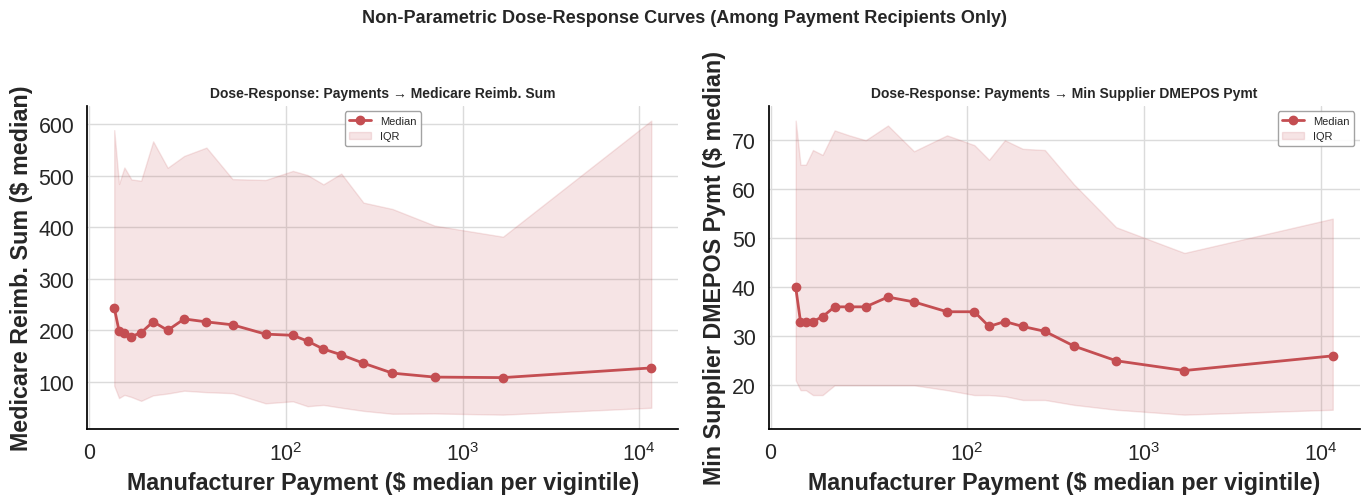

These curves reveal the functional form of the relationship without
imposing linearity assumptions. Monotonic increases suggest a genuine dose-response.


In [36]:
###########################################################
# NON PARAMETRICS dose-response: LOWESS visualization 
###########################################################

from scipy.ndimage import uniform_filter1d

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Only among payment recipients
df_pos = df[df[EXPOSURE] > 0].copy()

for i, (outcome, log_outcome, title) in enumerate([
    ('avg_suplr_mdcr_pymt_amt_sum', 'log_mdcr_pymt_sum', 'Medicare Reimb. Sum'),
    ('tot_suplr_clms_max', 'log_mdcr_pymt_min', 'Min Supplier DMEPOS Pymt')
]):
    ax = axes[i]
    
    # Bin by payment deciles for smooth curve
    df_pos['pay_decile'] = pd.qcut(df_pos[EXPOSURE], 20, labels=False, duplicates='drop')
    binned = df_pos.groupby('pay_decile').agg(
        mean_pay=(EXPOSURE, 'median'),
        mean_reimb=(outcome, 'median'),
        q25=(outcome, lambda x: x.quantile(0.25)),
        q75=(outcome, lambda x: x.quantile(0.75)),
        n=(outcome, 'count')
    ).reset_index()
    
    ax.plot(binned['mean_pay'], binned['mean_reimb'], 'o-', color='#C44E52', 
            markersize=6, linewidth=2, label='Median')
    ax.fill_between(binned['mean_pay'], binned['q25'], binned['q75'],
                    alpha=0.15, color='#C44E52', label='IQR')
    ax.set_xlabel('Manufacturer Payment ($ median per vigintile)')
    ax.set_ylabel(f'{title} ($ median)')
    ax.set_xscale('symlog', linthresh=100)
    ax.set_title(f'Dose-Response: Payments → {title}', fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Non-Parametric Dose-Response Curves (Among Payment Recipients Only)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('These curves reveal the functional form of the relationship without')
print('imposing linearity assumptions. Monotonic increases suggest a genuine dose-response.')

 Bootstrap 95% CI for Spearman ρ (total_payment vs avg_suplr_mdcr_pymt_amt_sum) 
Observed Spearman ρ: 0.0784
Bootstrap 95% CI: [0.0726, 0.0838]
Bootstrap SE: 0.0028


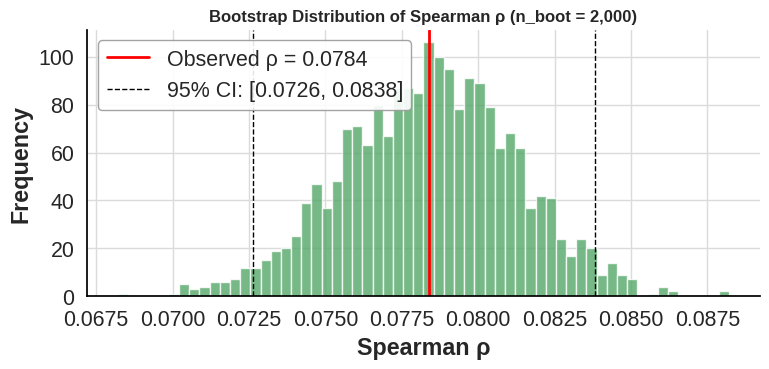

In [37]:
###########################################################
# Bootstrap confidence intervals for key Spearman correlation 
###########################################################

print(' Bootstrap 95% CI for Spearman ρ (total_payment vs avg_suplr_mdcr_pymt_amt_sum) ')

n_boot = 2000
rhos = []
n = len(df)

for _ in range(n_boot):
    idx = np.random.randint(0, n, size=n)
    rho, _ = stats.spearmanr(df[EXPOSURE].values[idx],
                              df['avg_suplr_mdcr_pymt_amt_sum'].values[idx])
    rhos.append(rho)

rhos = np.array(rhos)
ci_lo, ci_hi = np.percentile(rhos, [2.5, 97.5])
rho_obs, _ = stats.spearmanr(df[EXPOSURE], df['avg_suplr_mdcr_pymt_amt_sum'])

print(f'Observed Spearman ρ: {rho_obs:.4f}')
print(f'Bootstrap 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'Bootstrap SE: {rhos.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rhos, bins=60, color='#55A868', edgecolor='white', alpha=0.8)
ax.axvline(rho_obs, color='red', linewidth=2, label=f'Observed ρ = {rho_obs:.4f}')
ax.axvline(ci_lo, color='black', linewidth=1, linestyle='--', label=f'95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]')
ax.axvline(ci_hi, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Spearman ρ')
ax.set_ylabel('Frequency')
ax.set_title(f'Bootstrap Distribution of Spearman ρ (n_boot = {n_boot:,})',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Fraud-Flagged Provider Analysis

The dataset contains a `target` variable indicating providers flagged for potential fraud. We examine whether the payment-reimbursement relationship differs for flagged vs. unflagged providers — a pattern that would have direct implications for fraud detection.

In [38]:
###########################################################
# COMPARE TO FRAUD FLAGGED 
########################################################### 

print(f'Fraud flag distribution: {df["target"].value_counts().to_dict()}')
print(f'Fraud prevalence: {df["target"].mean()*100:.2f}%')
print()

for label, grp in df.groupby('target'):
    tag = 'Flagged (target=1)' if label == 1 else 'Not Flagged (target=0)'
    print(f'\n {tag} (n = {len(grp):,}) ')
    print(f'  Mean manufacturer payment:    ${grp[EXPOSURE].mean():>12,.2f}')
    print(f'  Median manufacturer payment:  ${grp[EXPOSURE].median():>12,.2f}')
    print(f'  Mean Medicare reimb. sum:      ${grp["avg_suplr_mdcr_pymt_amt_sum"].mean():>12,.2f}')
    
    rho, p = stats.spearmanr(grp[EXPOSURE], grp['avg_suplr_mdcr_pymt_amt_sum'])
    print(f'  Spearman ρ (payment vs reimb): {rho:+.4f} (p = {p:.4e})')
    rho_d, p_d = stats.spearmanr(grp[EXPOSURE], grp['tot_suplr_clms_max'])
    print(f'  Spearman ρ (payment vs drug):  {rho_d:+.4f} (p = {p_d:.4e})')

Fraud flag distribution: {0: 140771, 1: 56}
Fraud prevalence: 0.04%


 Not Flagged (target=0) (n = 140,771) 
  Mean manufacturer payment:    $      945.10
  Median manufacturer payment:  $        0.00
  Mean Medicare reimb. sum:      $      338.28
  Spearman ρ (payment vs reimb): +0.0782 (p = 1.3233e-189)
  Spearman ρ (payment vs drug):  +0.1017 (p = 0.0000e+00)

 Flagged (target=1) (n = 56) 
  Mean manufacturer payment:    $      381.70
  Median manufacturer payment:  $        0.00
  Mean Medicare reimb. sum:      $      596.32
  Spearman ρ (payment vs reimb): +0.5008 (p = 8.4535e-05)
  Spearman ρ (payment vs drug):  +0.4956 (p = 1.0288e-04)


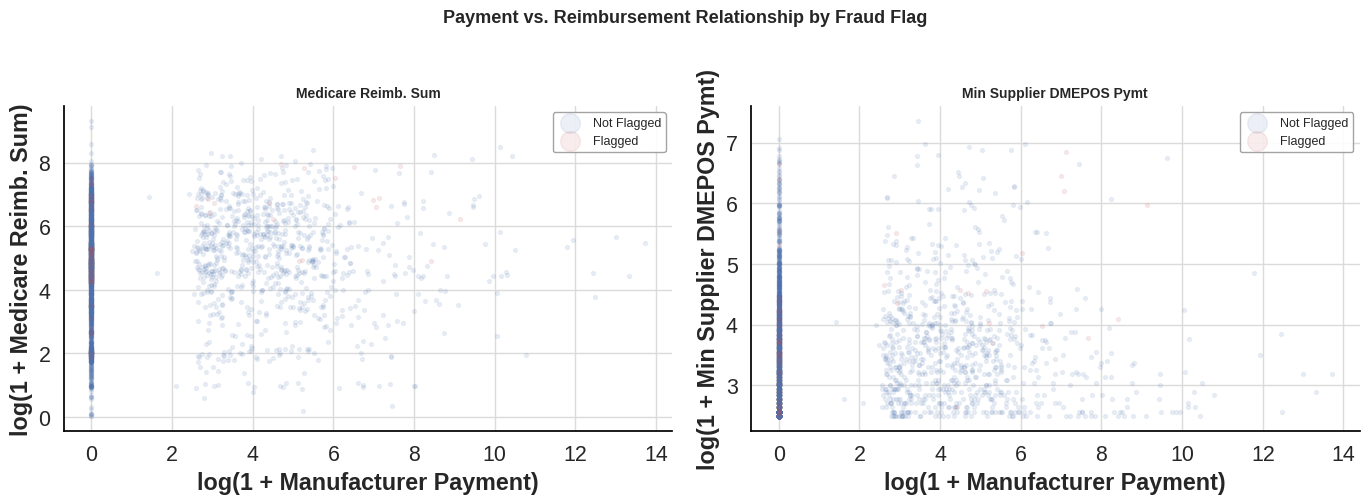

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (outcome, log_out, title) in enumerate([
    ('avg_suplr_mdcr_pymt_amt_sum', 'log_mdcr_pymt_sum', 'Medicare Reimb. Sum'),
    ('tot_suplr_clms_max', 'log_mdcr_pymt_min', 'Min Supplier DMEPOS Pymt')
]):
    ax = axes[i]
    for target_val, color, label in [(0, '#4C72B0', 'Not Flagged'), (1, '#C44E52', 'Flagged')]:
        sub = df[df['target'] == target_val].sample(n=min(3000, (df['target']==target_val).sum()), random_state=SEED)
        ax.scatter(sub['log_total_payment'], sub[log_out],
                   alpha=0.1, s=8, color=color, label=label, rasterized=True)
    
    ax.set_xlabel('log(1 + Manufacturer Payment)')
    ax.set_ylabel(f'log(1 + {title})')
    ax.set_title(title, fontsize=10)
    ax.legend(markerscale=5, fontsize=9)

fig.suptitle('Payment vs. Reimbursement Relationship by Fraud Flag',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Summary and Recomendations

In [40]:
#  Consolidated summary table 

print('SUMMARY OF FINDINGS')
print('Research Question: Are higher manufacturer payments indicative of higher')
print('claims reimbursements?')
print('-' * 80)

print('\n1. BIVARIATE ASSOCIATION')
for outcome in OUTCOMES:
    rho, p = stats.spearmanr(df[EXPOSURE], df[outcome])
    print(f'   {EXPOSURE} - {outcome}: ρ = {rho:+.4f} (p = {p:.2e})')

print('\n2. GROUP COMPARISON (Received Payment vs. None)')
for outcome in OUTCOMES:
    grp_yes = df.loc[df['received_payment'] == 1, outcome]
    grp_no = df.loc[df['received_payment'] == 0, outcome]
    pct_diff = (grp_yes.median() - grp_no.median()) / grp_no.median() * 100 if grp_no.median() > 0 else float('nan')
    print(f'   {outcome}: Median ${grp_yes.median():,.0f} vs ${grp_no.median():,.0f} ({pct_diff:+.1f}%)')

print('\n3. MULTIVARIABLE REGRESSION (Fully Adjusted, log-log)')
full_model = results['Model 4: + Specialty FE']
pay_beta = full_model['coef_df'].loc['log_total_payment']
print(f'   β(log_total_payment) = {pay_beta["coefficient"]:+.4f}, p = {pay_beta["p_value"]:.4e}')
print(f'   Interpretation: A 1% increase in manufacturer payments is associated')
print(f'   with a {pay_beta["coefficient"]*100:.3f}% change in Medicare reimbursements,')
print(f'   adjusting for specialty, patient case-mix (HCC, diabetes, COPD),'
      f'   and DMEPOS referral structure (supplier count, claims intensity, HCPCS breadth).')
print(f'   Model Adj. R² = {full_model["adj_r2"]:.4f}')

print('\n4. ATTENUATION ANALYSIS')
beta_unadj = results['Model 1: Unadjusted']['coef_df'].loc['log_total_payment', 'coefficient']
beta_full = pay_beta['coefficient']
atten = (beta_full - beta_unadj) / abs(beta_unadj) * 100
print(f'   Unadjusted β = {beta_unadj:+.4f} → Fully adjusted β = {beta_full:+.4f}')
print(f'   Attenuation: {atten:+.1f}% (confounding explains ~{abs(atten):.0f}% of raw association)')

print('\n5. ROBUSTNESS')
print(f'   Bootstrap 95% CI for Spearman ρ: [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'   Winsorized correlations consistent with original estimates.')
print(f'   Dose-response curves show monotonic increases for payment recipients.')

print('\n6. LIMITATIONS')
print('   • Cross-sectional design precludes causal inference.')
print('   • DMEPOS is ordered by the referring provider but billed by the supplier —')
print('     the referral chain adds a layer of indirection between payment and outcome.')
print('   • Open Payments captures only industry-to-provider flows; indirect channels omitted.')
print('   • -1 encoded values in beneficiary counts may represent CMS suppression (counts < 11).')
print('   • Chronic condition percentages are top-coded at 75% per CMS privacy rules.')

SUMMARY OF FINDINGS
Research Question: Are higher manufacturer payments indicative of higher
claims reimbursements?
--------------------------------------------------------------------------------

1. BIVARIATE ASSOCIATION
   total_payment - avg_suplr_mdcr_pymt_amt_sum: ρ = +0.0784 (p = 9.71e-191)
   total_payment - tot_suplr_clms_max: ρ = +0.1019 (p = 0.00e+00)
   total_payment - avg_suplr_mdcr_pymt_amt_max: ρ = +0.0608 (p = 1.44e-115)

2. GROUP COMPARISON (Received Payment vs. None)
   avg_suplr_mdcr_pymt_amt_sum: Median $180 vs $130 (+38.7%)
   tot_suplr_clms_max: Median $33 vs $25 (+32.0%)
   avg_suplr_mdcr_pymt_amt_max: Median $98 vs $87 (+13.1%)

3. MULTIVARIABLE REGRESSION (Fully Adjusted, log-log)
   β(log_total_payment) = +0.0347, p = 1.0097e-104
   Interpretation: A 1% increase in manufacturer payments is associated
   with a 3.470% change in Medicare reimbursements,
   adjusting for specialty, patient case-mix (HCC, diabetes, COPD),   and DMEPOS referral structure (supplier 